In [ ]:
!pip install medmnist
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import medmnist
from medmnist import INFO, Evaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Ορισμός seed για αναπαραγωγιμότητα
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.5 MB/s eta 0:00:00


In [5]:

dataset_name = 'pathmnist'

# Πληροφορίες dataset
info = INFO[dataset_name]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

print(f" ΠΛΗΡΟΦΟΡΙΕΣ DATASET ")
print(f"Όνομα: {dataset_name}")
print(f"Τύπος εικόνων: {'RGB' if n_channels == 3 else 'Grayscale'}")
print(f"Ανάλυση: 28x28 pixels")
print(f"Αριθμός κλάσεων: {n_classes}")
print(f"Κλάσεις: {info['label']}")
print(f"Task: {task}")

# Data transformation
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

if dataset_name == 'pathmnist':
    from medmnist import PathMNIST
    train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
    val_dataset = PathMNIST(split='val', transform=data_transform, download=True)
    test_dataset = PathMNIST(split='test', transform=data_transform, download=True)
elif dataset_name == 'chestmnist':
    from medmnist import ChestMNIST
    train_dataset = ChestMNIST(split='train', transform=data_transform, download=True)
    val_dataset = ChestMNIST(split='val', transform=data_transform, download=True)
    test_dataset = ChestMNIST(split='test', transform=data_transform, download=True)
elif dataset_name == 'organmnist':
    from medmnist import OrganMNIST
    train_dataset = OrganMNIST(split='train', transform=data_transform, download=True)
    val_dataset = OrganMNIST(split='val', transform=data_transform, download=True)
    test_dataset = OrganMNIST(split='test', transform=data_transform, download=True)
else:
    print(f"Προσθήκη κώδικα για το {dataset_name}")

print(f"\n ΜΕΓΕΘΗ DATASET ")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

 ΠΛΗΡΟΦΟΡΙΕΣ DATASET 
Όνομα: pathmnist
Τύπος εικόνων: RGB
Ανάλυση: 28x28 pixels
Αριθμός κλάσεων: 9
Κλάσεις: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Task: multi-class

 ΜΕΓΕΘΗ DATASET 
Training samples: 89996
Validation samples: 10004
Test samples: 7180


In [ ]:
!pip install medmnist
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import medmnist
from medmnist import INFO, Evaluator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Ορισμός seed για αναπαραγωγιμότητα
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.9 MB/s eta 0:00:00


In [3]:
from medmnist import INFO
import torchvision.transforms as transforms


 ΚΑΤΑΝΟΜΗ ΚΛΑΣΕΩΝ (Training) 
Κλάση 0 (Class 0): 9366 δείγματα (10.41%)
Κλάση 1 (Class 1): 9509 δείγματα (10.57%)
Κλάση 2 (Class 2): 10360 δείγματα (11.51%)
Κλάση 3 (Class 3): 10401 δείγματα (11.56%)
Κλάση 4 (Class 4): 8006 δείγματα (8.90%)
Κλάση 5 (Class 5): 12182 δείγματα (13.54%)
Κλάση 6 (Class 6): 7886 δείγματα (8.76%)
Κλάση 7 (Class 7): 9401 δείγματα (10.45%)
Κλάση 8 (Class 8): 12885 δείγματα (14.32%)

 ΚΑΤΑΝΟΜΗ ΚΛΑΣΕΩΝ (Validation) 
Κλάση 0 (Class 0): 1041 δείγματα (10.41%)
Κλάση 1 (Class 1): 1057 δείγματα (10.57%)
Κλάση 2 (Class 2): 1152 δείγματα (11.52%)
Κλάση 3 (Class 3): 1156 δείγματα (11.56%)
Κλάση 4 (Class 4): 890 δείγματα (8.90%)
Κλάση 5 (Class 5): 1354 δείγματα (13.53%)
Κλάση 6 (Class 6): 877 δείγματα (8.77%)
Κλάση 7 (Class 7): 1045 δείγματα (10.45%)
Κλάση 8 (Class 8): 1432 δείγματα (14.31%)

 ΚΑΤΑΝΟΜΗ ΚΛΑΣΕΩΝ (Test) 
Κλάση 0 (Class 0): 1338 δείγματα (18.64%)
Κλάση 1 (Class 1): 847 δείγματα (11.80%)
Κλάση 2 (Class 2): 339 δείγματα (4.72%)
Κλάση 3 (Class 3): 634 δείγματα 

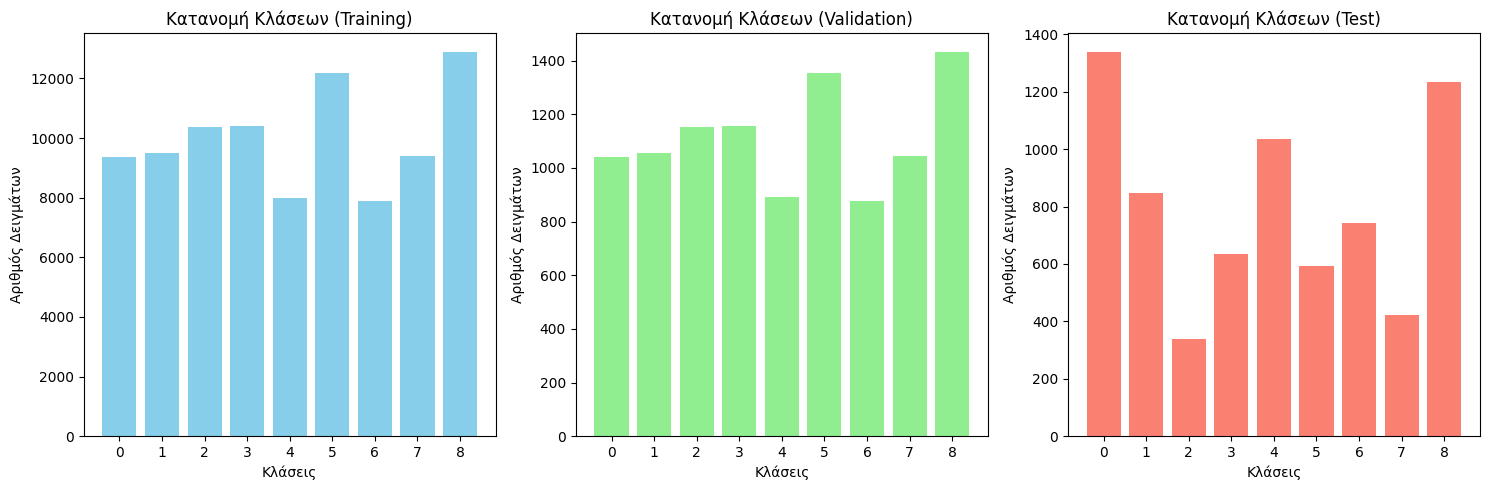


 ΑΝΑΛΥΣΗ ΙΣΟΡΡΟΠΙΑΣ ΚΛΑΣΕΩΝ 
Πιο πολυπληθής κλάση (Train): 12885 δείγματα
Λιγότερο πληθής κλάση (Train): 7886 δείγματα
Λόγος ανισορροπίας: 1.63
 ΟΚ - Καλή ισορροπία κλάσεων


In [8]:

def analyze_class_distribution(dataset, split_name):
    labels = []
    for i in range(len(dataset)):
        _, label = dataset[i]
        labels.append(label)

    labels = np.array(labels)
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n ΚΑΤΑΝΟΜΗ ΚΛΑΣΕΩΝ ({split_name}) ")
    for cls, count in zip(unique, counts):
        class_name = info['label'].get(cls, f'Class {cls}')
        print(f"Κλάση {cls} ({class_name}): {count} δείγματα ({count/len(dataset)*100:.2f}%)")

    return unique, counts

# Ανάλυση και για τα τρία splits
train_unique, train_counts = analyze_class_distribution(train_dataset, "Training")
val_unique, val_counts = analyze_class_distribution(val_dataset, "Validation")
test_unique, test_counts = analyze_class_distribution(test_dataset, "Test")

# Οπτικοποίηση κατανομής
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(train_unique, train_counts, color='skyblue')
plt.title('Κατανομή Κλάσεων (Training)')
plt.xlabel('Κλάσεις')
plt.ylabel('Αριθμός Δειγμάτων')
plt.xticks(train_unique)

plt.subplot(1, 3, 2)
plt.bar(val_unique, val_counts, color='lightgreen')
plt.title('Κατανομή Κλάσεων (Validation)')
plt.xlabel('Κλάσεις')
plt.ylabel('Αριθμός Δειγμάτων')
plt.xticks(val_unique)

plt.subplot(1, 3, 3)
plt.bar(test_unique, test_counts, color='salmon')
plt.title('Κατανομή Κλάσεων (Test)')
plt.xlabel('Κλάσεις')
plt.ylabel('Αριθμός Δειγμάτων')
plt.xticks(test_unique)

plt.tight_layout()
plt.show()

# Έλεγχος για class imbalance
print("\n ΑΝΑΛΥΣΗ ΙΣΟΡΡΟΠΙΑΣ ΚΛΑΣΕΩΝ ")
max_count_train = max(train_counts)
min_count_train = min(train_counts)
imbalance_ratio_train = max_count_train / min_count_train

print(f"Πιο πολυπληθής κλάση (Train): {max_count_train} δείγματα")
print(f"Λιγότερο πληθής κλάση (Train): {min_count_train} δείγματα")
print(f"Λόγος ανισορροπίας: {imbalance_ratio_train:.2f}")

if imbalance_ratio_train > 5:
    print("  ΥΠΑΡΧΕΙ ΣΗΜΑΝΤΙΚΗ ΑΝΙΣΟΡΡΟΠΙΑ ΚΛΑΣΕΩΝ!")
elif imbalance_ratio_train > 2:
    print("ℹ  Υπάρχει μέτρια ανισορροπία κλάσεων")
else:
    print(" ΟΚ - Καλή ισορροπία κλάσεων")

 ΠΑΡΑΔΕΙΓΜΑΤΑ ΕΙΚΟΝΩΝ ΑΠΟ ΚΑΘΕ ΚΛΑΣΗ 


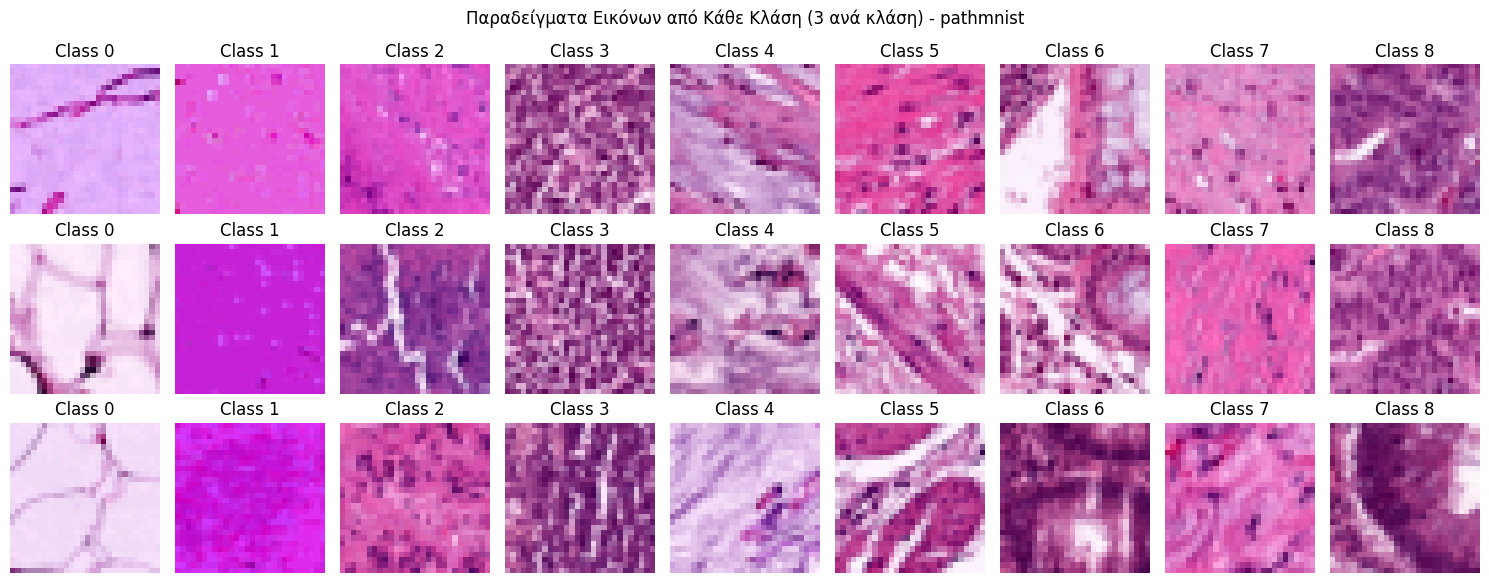


 ΤΥΧΑΙΕΣ ΕΙΚΟΝΕΣ ΑΠΟ ΤΟ DATASET 


/tmp/ipython-input-3654713181.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_name = info['label'].get(int(label), f'Class {label}')


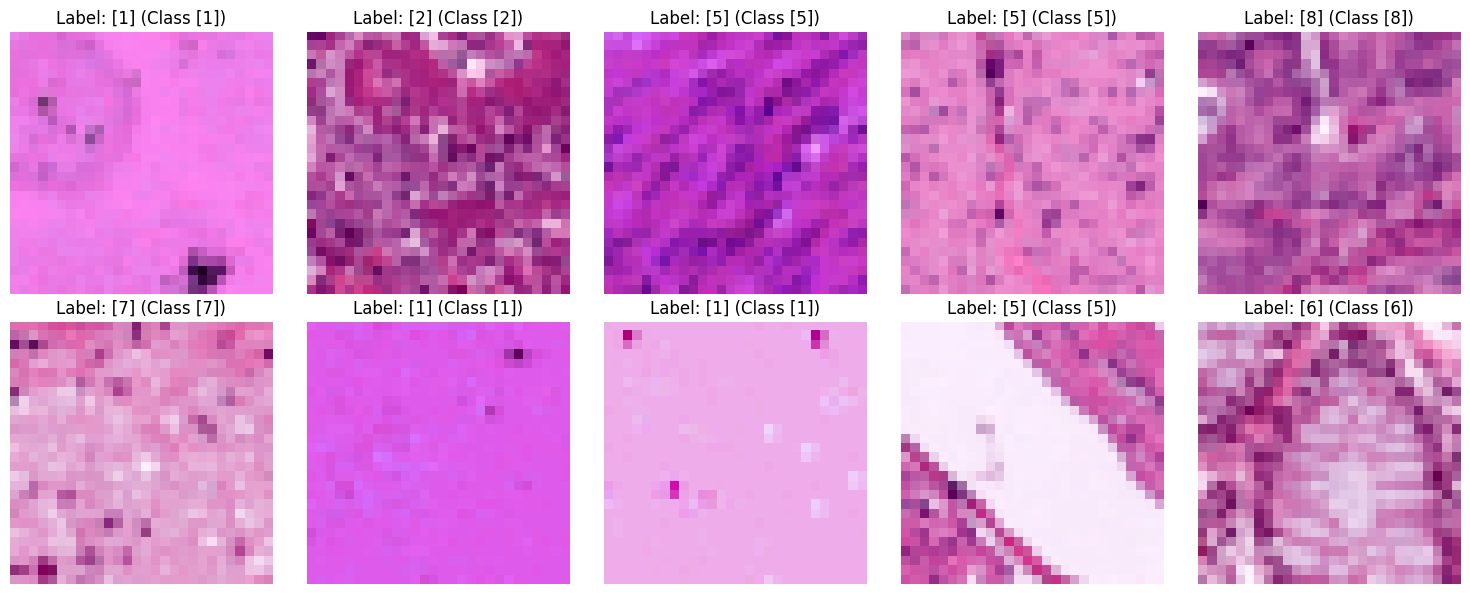

In [9]:
#Οπτικοποίηση παραδειγμάτων εικόνων
def show_examples(dataset, n_classes, n_examples=3):
    fig, axes = plt.subplots(n_examples, n_classes, figsize=(15, 2*n_examples))

    # Αν έχουμε μόνο 1 παράδειγμα ανά κλάση, φτιάξε 2D axes
    if n_examples == 1:
        axes = axes.reshape(1, -1)

    for cls in range(n_classes):
        #εικόνες της τρέχουσας κλάσης
        class_indices = []
        for i in range(len(dataset)):
            _, label = dataset[i]
            if label == cls:
                class_indices.append(i)
            if len(class_indices) >= n_examples:
                break

        for idx, img_idx in enumerate(class_indices):
            image, label = dataset[img_idx]

            # Μετατροπή για plotting
            if image.shape[0] == 1:  # Grayscale
                image = image.squeeze().numpy()
                if n_examples > 1:
                    axes[idx, cls].imshow(image, cmap='gray')
                    axes[idx, cls].set_title(f'Class {cls}')
                    axes[idx, cls].axis('off')
                else:
                    axes[cls].imshow(image, cmap='gray')
                    axes[cls].set_title(f'Class {cls}')
                    axes[cls].axis('off')
            else:  # RGB
                image = image.permute(1, 2, 0).numpy()
                image = (image - image.min()) / (image.max() - image.min())  # Normalize to [0,1]
                if n_examples > 1:
                    axes[idx, cls].imshow(image)
                    axes[idx, cls].set_title(f'Class {cls}')
                    axes[idx, cls].axis('off')
                else:
                    axes[cls].imshow(image)
                    axes[cls].set_title(f'Class {cls}')
                    axes[cls].axis('off')

    plt.suptitle(f'Παραδείγματα Εικόνων από Κάθε Κλάση ({n_examples} ανά κλάση) - {dataset_name}')
    plt.tight_layout()
    plt.show()

# Εμφάνιση παραδειγμάτων από το training set
print(" ΠΑΡΑΔΕΙΓΜΑΤΑ ΕΙΚΟΝΩΝ ΑΠΟ ΚΑΘΕ ΚΛΑΣΗ ")
show_examples(train_dataset, n_classes, n_examples=3)

# Εμφάνιση μερικών τυχαίων εικόνων για καλύτερη οπτικοποίηση
print("\n ΤΥΧΑΙΕΣ ΕΙΚΟΝΕΣ ΑΠΟ ΤΟ DATASET ")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    idx = np.random.randint(len(train_dataset))
    image, label = train_dataset[idx]

    row, col = i // 5, i % 5

    if image.shape[0] == 1:  # Grayscale
        image_display = image.squeeze().numpy()
        axes[row, col].imshow(image_display, cmap='gray')
    else:  # RGB
        image_display = image.permute(1, 2, 0).numpy()
        image_display = (image_display - image_display.min()) / (image_display.max() - image_display.min())
        axes[row, col].imshow(image_display)

    class_name = info['label'].get(int(label), f'Class {label}')
    axes[row, col].set_title(f'Label: {label} ({class_name})')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Ορισμός CNN Architecture
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNN, self).__init__()

        # Block 1: 32 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        # Block 2: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        # Layer Normalization (αν χρησιμοποιείται)
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(128)  # LayerNorm μετά το τελευταίο block

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 512)  # 28x28 -> 14x14 -> 7x7 -> 3x3 μετά από 3 pooling
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        if self.bn1 is not None:
            x = self.bn1(x)
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.conv2(x))
        if self.bn2 is not None:
            x = self.bn2(x)
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.conv3(x))
        if self.bn3 is not None:
            x = self.bn3(x)
        x = self.pool3(x)

        # Layer Normalization (αν ενεργοποιημένη)
        if self.use_layernorm:
            x = self.ln(x)

        # Flatten και fully connected
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

#Επαναφορά των μεταβλητών από το dataset
print("  ΕΠΑΝΑΦΟΡΑ ΠΛΗΡΟΦΟΡΙΩΝ DATASET ")

# Επιβεβαίωση dataset που έχουμε
if 'dataset_name' in locals():
    print(f"Dataset: {dataset_name}")
    info = INFO[dataset_name]
    n_classes = len(info['label'])
    n_channels = info['n_channels']
else:
    # Default values για PathMNIST
    dataset_name = 'pathmnist'
    info = INFO[dataset_name]
    n_classes = len(info['label'])
    n_channels = info['n_channels']
    print(f"Χρήση default dataset: {dataset_name}")

print(f"Αριθμός κλάσεων: {n_classes}")
print(f"Τύπος εικόνων: {n_channels} channels")
print(f"Μέγεθος εικόνας: 28x28")
print(f"Κλάσεις: {info['label']}")

# Δοκιμή του μοντέλου
print("\n=== ΔΟΚΙΜΗ CNN ===")
model = BasicCNN(num_classes=n_classes, use_batchnorm=True)
print(f"Αριθμός παραμέτρων: {sum(p.numel() for p in model.parameters()):,}")

# Δοκιμή forward pass
test_input = torch.randn(2, 3, 28, 28)  # batch_size=2, channels=3, height=28, width=28
output = model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output για πρώτο δείγμα: {output[0]}")

  ΕΠΑΝΑΦΟΡΑ ΠΛΗΡΟΦΟΡΙΩΝ DATASET 
Χρήση default dataset: pathmnist
Αριθμός κλάσεων: 9
Τύπος εικόνων: 3 channels
Μέγεθος εικόνας: 28x28
Κλάσεις: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

=== ΔΟΚΙΜΗ CNN ===
Αριθμός παραμέτρων: 688,649
Input shape: torch.Size([2, 3, 28, 28])
Output shape: torch.Size([2, 9])
Output για πρώτο δείγμα: tensor([-0.3039,  1.1123,  0.0746,  0.3633, -0.6165,  0.4907, -0.0989, -0.0396,
        -1.0358], grad_fn=<SelectBackward0>)


In [ ]:
#  Γρήγορη επαναφορά
print(" ΓΡΗΓΟΡΗ ΕΠΑΝΑΦΟΡΑ DATASET ")

# Επανάληψη της φόρτωσης dataset
dataset_name = 'pathmnist'  # ή όποιο διάλεξες
info = INFO[dataset_name]
n_classes = len(info['label'])
n_channels = info['n_channels']

print(f"Dataset: {dataset_name}")
print(f"Αριθμός κλάσεων: {n_classes}")
print(f"Τύπος εικόνων: {n_channels} channels")


 ΓΡΗΓΟΡΗ ΕΠΑΝΑΦΟΡΑ DATASET 
Dataset: pathmnist
Αριθμός κλάσεων: 9
Τύπος εικόνων: 3 channels


In [ ]:
# Ορισμός CNN Architecture
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNN, self).__init__()

        # Block 1: 32 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        # Block 2: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        # Layer Normalization (αν χρησιμοποιείται)
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(128)  # LayerNorm μετά το τελευταίο block

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 512)  # 28x28 -> 14x14 -> 7x7 -> 3x3 μετά από 3 pooling
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        if self.bn1 is not None:
            x = self.bn1(x)
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.conv2(x))
        if self.bn2 is not None:
            x = self.bn2(x)
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.conv3(x))
        if self.bn3 is not None:
            x = self.bn3(x)
        x = self.pool3(x)

        # Layer Normalization (αν ενεργοποιημένη)
        if self.use_layernorm:
            x = self.ln(x)

        # Flatten και fully connected
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

#  Επαναφορά των μεταβλητών από το dataset
print(" ΕΠΑΝΑΦΟΡΑ ΠΛΗΡΟΦΟΡΙΩΝ DATASET ")

# Επιβεβαίωση dataset που έχουμε
if 'dataset_name' in locals():
    print(f"Dataset: {dataset_name}")
    info = INFO[dataset_name]
    n_classes = len(info['label'])
    n_channels = info['n_channels']
else:
    # Default values για PathMNIST
    dataset_name = 'pathmnist'
    info = INFO[dataset_name]
    n_classes = len(info['label'])
    n_channels = info['n_channels']
    print(f"Χρήση default dataset: {dataset_name}")

print(f"Αριθμός κλάσεων: {n_classes}")
print(f"Τύπος εικόνων: {n_channels} channels")
print(f"Μέγεθος εικόνας: 28x28")
print(f"Κλάσεις: {info['label']}")

# Δοκιμή του μοντέλου
print("\n=== ΔΟΚΙΜΗ CNN ===")
model = BasicCNN(num_classes=n_classes, use_batchnorm=True)
print(f"Αριθμός παραμέτρων: {sum(p.numel() for p in model.parameters()):,}")

# Δοκιμή forward pass
test_input = torch.randn(2, 3, 28, 28)  # batch_size=2, channels=3, height=28, width=28
output = model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output για πρώτο δείγμα: {output[0]}")

=== ΕΠΑΝΑΦΟΡΑ ΠΛΗΡΟΦΟΡΙΩΝ DATASET ===
Dataset: pathmnist
Αριθμός κλάσεων: 9
Τύπος εικόνων: 3 channels
Μέγεθος εικόνας: 28x28
Κλάσεις: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

=== ΔΟΚΙΜΗ CNN ===
Αριθμός παραμέτρων: 688,649
Input shape: torch.Size([2, 3, 28, 28])
Output shape: torch.Size([2, 9])
Output για πρώτο δείγμα: tensor([ 1.0762,  0.1658, -0.5130,  1.8702, -0.0512,  0.5023,  0.5954, -0.7247,
        -0.6553], grad_fn=<SelectBackward0>)


In [ ]:
#  Προετοιμασία DataLoaders και training functions
from torch.utils.data import DataLoader
import time

# Δημιουργία DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device='cuda'):
    model.to(device)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device).squeeze()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

# Έλεγχος για GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Χρήση συσκευής: {device}")

Train batches: 1407
Val batches: 157
Test batches: 113
Χρήση συσκευής: cpu


In [ ]:
# ΠΛΗΡΗ ΕΚΠΑΙΔΕΥΣΗ - CNN ΧΩΡΙΣ NORMALIZATION
print("ΕΚΠΑΙΔΕΥΣΗ 1: CNN ΧΩΡΙΣ NORMALIZATION ")

# 1. ΕΓΚΑΤΑΣΤΑΣΗ medmnist (αν δεν υπάρχει)
print("Εγκατάσταση βιβλιοθηκών...")
!pip install medmnist

# 2. Εισαγωγή όλων των βιβλιοθηκών
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO

# 3. Ορισμός dataset και φόρτωση
print("Φόρτωση dataset...")
dataset_name = 'pathmnist'  # ή όποιο διάλεξες
info = INFO[dataset_name]
n_classes = len(info['label'])
n_channels = info['n_channels']

print(f"Dataset: {dataset_name}")
print(f"Αριθμός κλάσεων: {n_classes}")
print(f"Κλάσεις: {info['label']}")

# 4. Φόρτωση datasets
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

if dataset_name == 'pathmnist':
    from medmnist import PathMNIST
    train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
    val_dataset = PathMNIST(split='val', transform=data_transform, download=True)
    test_dataset = PathMNIST(split='test', transform=data_transform, download=True)
elif dataset_name == 'chestmnist':
    from medmnist import ChestMNIST
    train_dataset = ChestMNIST(split='train', transform=data_transform, download=True)
    val_dataset = ChestMNIST(split='val', transform=data_transform, download=True)
    test_dataset = ChestMNIST(split='test', transform=data_transform, download=True)
elif dataset_name == 'organmnist':
    from medmnist import OrganMNIST
    train_dataset = OrganMNIST(split='train', transform=data_transform, download=True)
    val_dataset = OrganMNIST(split='val', transform=data_transform, download=True)
    test_dataset = OrganMNIST(split='test', transform=data_transform, download=True)

# 5. Δημιουργία DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# 6. Ορισμός BasicCNN
class BasicCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNN, self).__init__()

        # Block 1: 32 filters
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        # Block 2: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(128)

        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)

        if self.use_layernorm: x = self.ln(x)

        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 7. Ορισμός training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device='cpu'):
    model.to(device)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

# 8. Εκπαίδευση μοντέλου
print("\n=== ΞΕΚΙΝΑΕΙ ΕΚΠΑΙΔΕΥΣΗ ===")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Χρήση συσκευής: {device}")

model_no_norm = BasicCNN(num_classes=n_classes, use_batchnorm=False, dropout_rate=0.0)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_no_norm.parameters(), lr=1e-3)

print(f"Μοντέλο: CNN χωρίς normalization")
print(f"Learning rate: 1e-3")
print(f"Batch size: 64")
print(f"Epochs: 30")

train_losses_1, val_losses_1, train_accs_1, val_accs_1 = train_model(
    model_no_norm, train_loader, val_loader, criterion, optimizer,
    num_epochs=30, device=device
)

print(" ΟΛΟΚΛΗΡΩΣΗ ΠΡΩΤΗΣ ΕΚΠΑΙΔΕΥΣΗΣ!")

=== ΕΚΠΑΙΔΕΥΣΗ 1: CNN ΧΩΡΙΣ NORMALIZATION ===
Εγκατάσταση βιβλιοθηκών...
Φόρτωση dataset...
Dataset: pathmnist
Αριθμός κλάσεων: 9
Κλάσεις: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Train batches: 1407
Validation batches: 157

=== ΞΕΚΙΝΑΕΙ ΕΚΠΑΙΔΕΥΣΗ ===
Χρήση συσκευής: cpu
Μοντέλο: CNN χωρίς normalization
Learning rate: 1e-3
Batch size: 64
Epochs: 30
Epoch [10/30], Train Loss: 0.0887, Train Acc: 96.78%, Val Loss: 0.1857, Val Acc: 94.29%
Epoch [20/30], Train Loss: 0.0391, Train Acc: 98.64%, Val Loss: 0.2944, Val Acc: 93.81%
Epoch [30/30], Train Loss: 0.0299, Train Acc: 99.00%, Val Loss: 0.4745, Val Acc: 92.34%
✅ ΟΛΟΚΛΗΡΩΣΗ ΠΡΩΤΗΣ ΕΚΠΑΙΔΕΥΣΗΣ!


=== ΕΚΠΑΙΔΕΥΣΗ 1: CNN ΧΩΡΙΣ NORMALIZATION ===
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.1 MB/s eta 0:00:00


100%|██████████| 206M/206M [00:11<00:00, 18.1MB/s]


Epoch [10/30], Train Loss: 0.0922, Train Acc: 96.68%, Val Loss: 0.2197, Val Acc: 93.68%
Epoch [20/30], Train Loss: 0.0417, Train Acc: 98.62%, Val Loss: 0.3516, Val Acc: 92.84%
Epoch [30/30], Train Loss: 0.0328, Train Acc: 98.97%, Val Loss: 0.3030, Val Acc: 93.55%

=== ΑΠΟΤΕΛΕΣΜΑΤΑ ΕΚΠΑΙΔΕΥΣΗΣ 1 ===


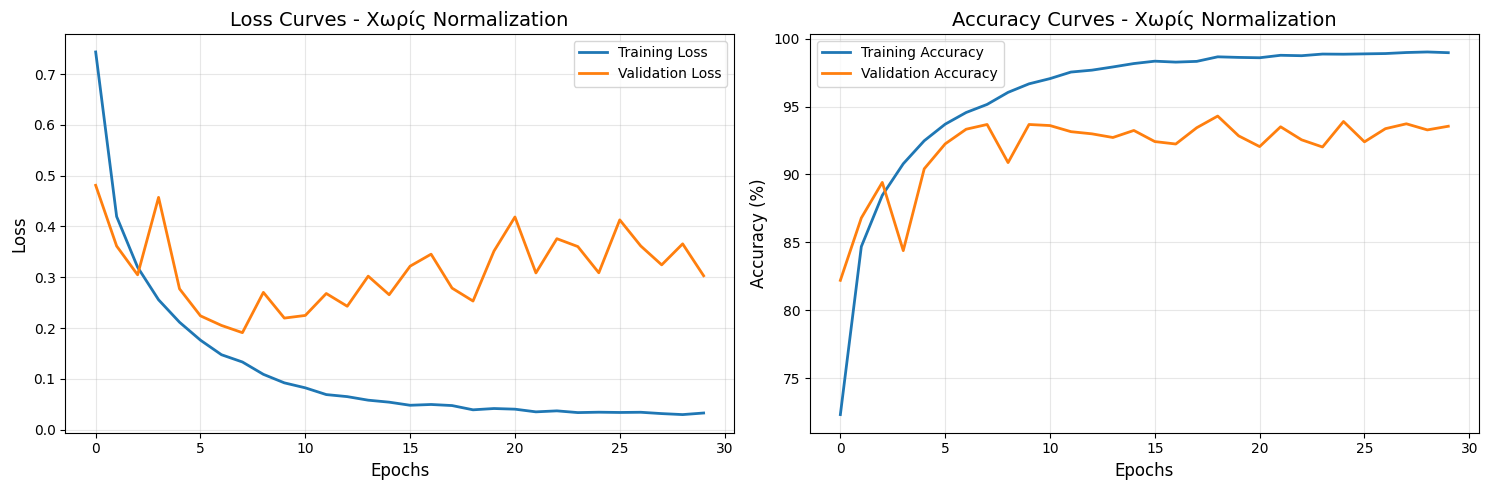


📊 ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:
   Training Accuracy: 98.97%
   Validation Accuracy: 93.55%
   Training Loss: 0.0328
   Validation Loss: 0.3030
ℹ️  Μέτρια υπερεκπαίδευση (διαφορά 5.4%)

✅ ΟΛΟΚΛΗΡΩΣΗ ΠΡΩΤΗΣ ΕΚΠΑΙΔΕΥΣΗΣ!


In [ ]:
#  ΠΛΗΡΗ ΕΚΠΑΙΔΕΥΣΗ ΚΑΙ ΑΝΑΛΥΣΗ - CNN ΧΩΡΙΣ NORMALIZATION

#  ΜΕΡΟΣ 1: ΕΚΠΑΙΔΕΥΣΗ
print(" ΕΚΠΑΙΔΕΥΣΗ 1: CNN ΧΩΡΙΣ NORMALIZATION ")

# 1. Εγκατάσταση/εισαγωγή
!pip install medmnist -q
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO

# 2. Dataset
dataset_name = 'pathmnist'
info = INFO[dataset_name]
n_classes = len(info['label'])

# 3. Φόρτωση
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

from medmnist import PathMNIST
train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
val_dataset = PathMNIST(split='val', transform=data_transform, download=True)

# 4. DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 5. BasicCNN κλάση
class BasicCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(128)
        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)
        if self.use_layernorm: x = self.ln(x)
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 6. Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device='cpu'):
    model.to(device)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

# 7. Εκπαίδευση
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_no_norm = BasicCNN(num_classes=n_classes, use_batchnorm=False, dropout_rate=0.0)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_no_norm.parameters(), lr=1e-3)

train_losses_1, val_losses_1, train_accs_1, val_accs_1 = train_model(
    model_no_norm, train_loader, val_loader, criterion, optimizer,
    num_epochs=30, device=device
)

#ΜΕΡΟΣ 2: ΑΝΑΛΥΣΗ
print("\n ΑΠΟΤΕΛΕΣΜΑΤΑ ΕΚΠΑΙΔΕΥΣΗΣ 1 ")

# Οπτικοποίηση
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_1, label='Training Loss', linewidth=2)
plt.plot(val_losses_1, label='Validation Loss', linewidth=2)
plt.title('Loss Curves - Χωρίς Normalization', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs_1, label='Training Accuracy', linewidth=2)
plt.plot(val_accs_1, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curves - Χωρίς Normalization', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Τελικές μετρικές
print(f"\n📊 ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:")
print(f"   Training Accuracy: {train_accs_1[-1]:.2f}%")
print(f"   Validation Accuracy: {val_accs_1[-1]:.2f}%")
print(f"   Training Loss: {train_losses_1[-1]:.4f}")
print(f"   Validation Loss: {val_losses_1[-1]:.4f}")

# Ανάλυση
diff = train_accs_1[-1] - val_accs_1[-1]
if diff > 10:
    print(f"  ΣΗΜΑΝΤΙΚΗ ΥΠΕΡΕΚΠΑΙΔΕΥΣΗ! (διαφορά {diff:.1f}%)")
elif diff > 5:
    print(f"  Μέτρια υπερεκπαίδευση (διαφορά {diff:.1f}%)")
else:
    print(f" ΚΑΛΗ ΓΕΝΙΚΕΥΣΗ! (διαφορά {diff:.1f}%)")

print("\n ΟΛΟΚΛΗΡΩΣΗ ΠΡΩΤΗΣ ΕΚΠΑΙΔΕΥΣΗΣ!")

=== ΕΚΠΑΙΔΕΥΣΗ 1: CNN ΧΩΡΙΣ NORMALIZATION ===
Epoch [10/30], Train Loss: 0.0975, Train Acc: 96.49%, Val Loss: 0.2045, Val Acc: 93.92%
Epoch [20/30], Train Loss: 0.0379, Train Acc: 98.70%, Val Loss: 0.3191, Val Acc: 93.26%
Epoch [30/30], Train Loss: 0.0317, Train Acc: 98.94%, Val Loss: 0.3431, Val Acc: 93.98%

=== ΑΠΟΤΕΛΕΣΜΑΤΑ ΕΚΠΑΙΔΕΥΣΗΣ 1 ===


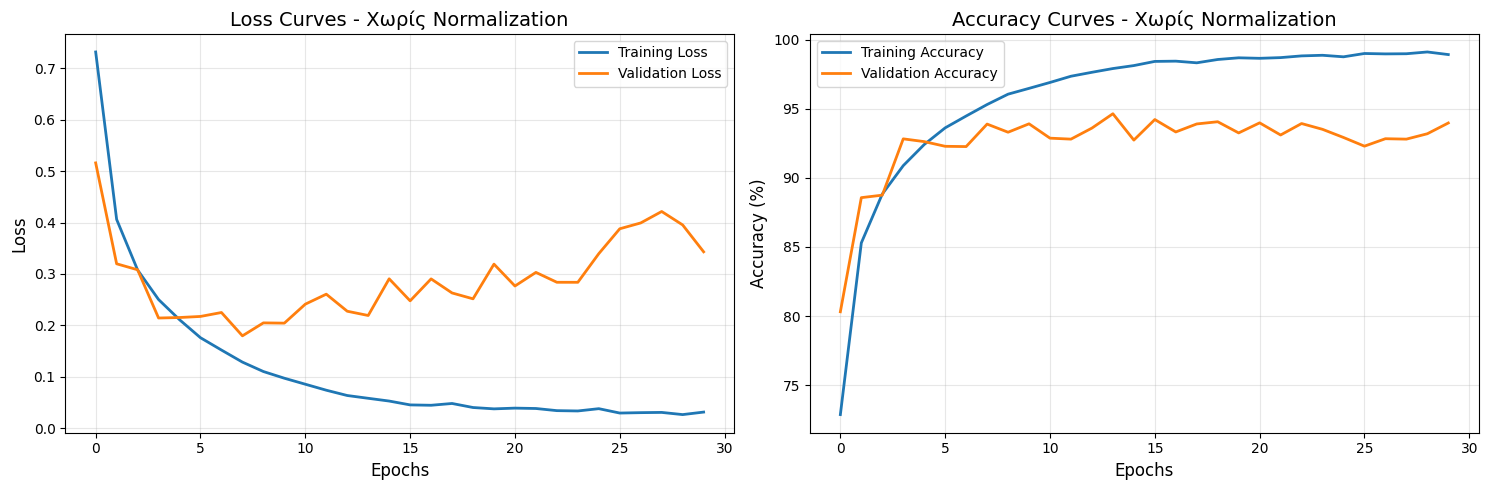


📊 ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:
   Training Accuracy: 98.94%
   Validation Accuracy: 93.98%
   Training Loss: 0.0317
   Validation Loss: 0.3431
✅ ΚΑΛΗ ΓΕΝΙΚΕΥΣΗ! (διαφορά 5.0%)

✅ ΟΛΟΚΛΗΡΩΣΗ ΠΡΩΤΗΣ ΕΚΠΑΙΔΕΥΣΗΣ!


In [ ]:
#  ΠΛΗΡΗ ΕΚΠΑΙΔΕΥΣΗ ΚΑΙ ΑΝΑΛΥΣΗ - CNN ΧΩΡΙΣ NORMALIZATION

#  ΜΕΡΟΣ 1: ΕΚΠΑΙΔΕΥΣΗ
print(" ΕΚΠΑΙΔΕΥΣΗ 1: CNN ΧΩΡΙΣ NORMALIZATION ")

# 1. Εγκατάσταση/εισαγωγή
!pip install medmnist -q
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO

# 2. Dataset
dataset_name = 'pathmnist'
info = INFO[dataset_name]
n_classes = len(info['label'])

# 3. Φόρτωση
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

from medmnist import PathMNIST
train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
val_dataset = PathMNIST(split='val', transform=data_transform, download=True)

# 4. DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 5. BasicCNN κλάση
class BasicCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(128)
        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)
        if self.use_layernorm: x = self.ln(x)
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 6. Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device='cpu'):
    model.to(device)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    return train_losses, val_losses, train_accs, val_accs

# 7. Εκπαίδευση
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_no_norm = BasicCNN(num_classes=n_classes, use_batchnorm=False, dropout_rate=0.0)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_no_norm.parameters(), lr=1e-3)

train_losses_1, val_losses_1, train_accs_1, val_accs_1 = train_model(
    model_no_norm, train_loader, val_loader, criterion, optimizer,
    num_epochs=30, device=device
)

#ΜΕΡΟΣ 2: ΑΝΑΛΥΣΗ
print("\n ΑΠΟΤΕΛΕΣΜΑΤΑ ΕΚΠΑΙΔΕΥΣΗΣ 1 ")

# Οπτικοποίηση
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_1, label='Training Loss', linewidth=2)
plt.plot(val_losses_1, label='Validation Loss', linewidth=2)
plt.title('Loss Curves - Χωρίς Normalization', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_accs_1, label='Training Accuracy', linewidth=2)
plt.plot(val_accs_1, label='Validation Accuracy', linewidth=2)
plt.title('Accuracy Curves - Χωρίς Normalization', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Τελικές μετρικές
print(f"\n ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:")
print(f"   Training Accuracy: {train_accs_1[-1]:.2f}%")
print(f"   Validation Accuracy: {val_accs_1[-1]:.2f}%")
print(f"   Training Loss: {train_losses_1[-1]:.4f}")
print(f"   Validation Loss: {val_losses_1[-1]:.4f}")

# Ανάλυση
diff = train_accs_1[-1] - val_accs_1[-1]
if diff > 10:
    print(f"  ΣΗΜΑΝΤΙΚΗ ΥΠΕΡΕΚΠΑΙΔΕΥΣΗ! (διαφορά {diff:.1f}%)")
elif diff > 5:
    print(f"ℹ  Μέτρια υπερεκπαίδευση (διαφορά {diff:.1f}%)")
else:
    print(f" ΚΑΛΗ ΓΕΝΙΚΕΥΣΗ! (διαφορά {diff:.1f}%)")

print("\n ΟΛΟΚΛΗΡΩΣΗ ΠΡΩΤΗΣ ΕΚΠΑΙΔΕΥΣΗΣ!")

=== ΕΚΠΑΙΔΕΥΣΗ 2: CNN ΜΕ BATCH NORMALIZATION ===
Σύγκριση με προηγούμενο: Χωρίς normalization
Validation accuracy χωρίς normalization: 93.98%

Ξεκινάει εκπαίδευση με Batch Normalization...
Learning rate: 5e-4 (σύμφωνα με οδηγίες)
Epochs: 30
Epoch [10/30], Train Loss: 0.0475, Train Acc: 98.37%, Val Loss: 0.2491, Val Acc: 93.67%
Epoch [20/30], Train Loss: 0.0268, Train Acc: 99.13%, Val Loss: 0.2658, Val Acc: 94.47%
Epoch [30/30], Train Loss: 0.0197, Train Acc: 99.38%, Val Loss: 0.3602, Val Acc: 93.45%

=== ΑΠΟΤΕΛΕΣΜΑΤΑ BATCH NORM ===


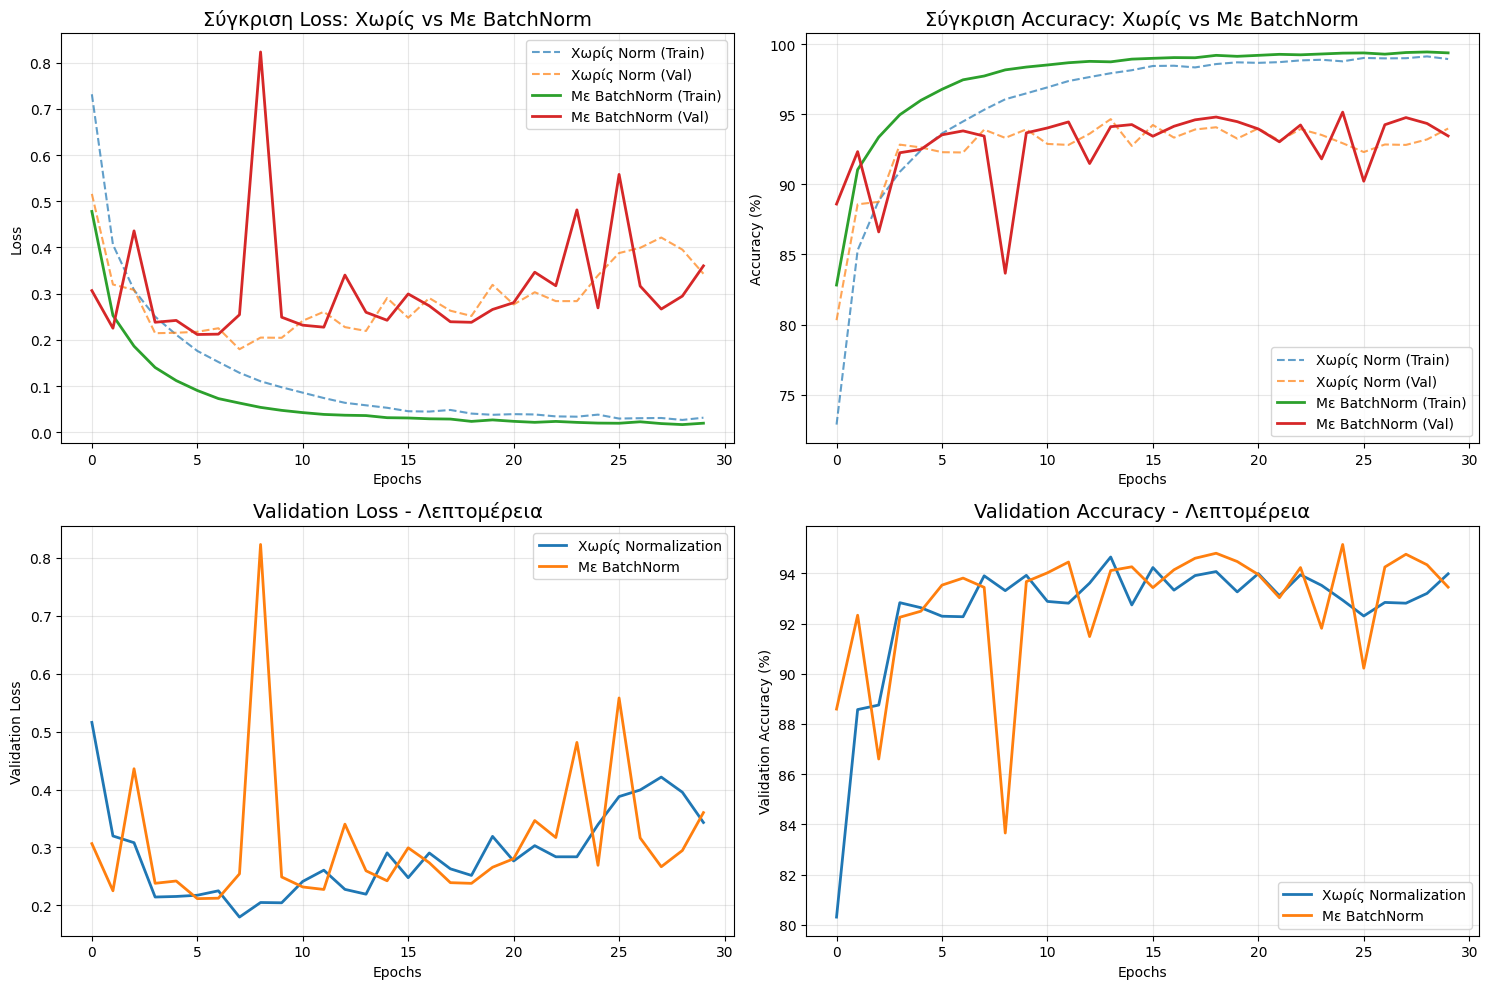


📊 ΣΥΓΚΡΙΤΙΚΗ ΑΝΑΛΥΣΗ:
ΜΕΤΡΙΚΗ                   ΧΩΡΙΣ NORM      ΜΕ BATCHNORM    ΔΙΑΦΟΡΑ   
-----------------------------------------------------------------
Validation Accuracy (%)   93.98           93.45           -0.53     
Training Accuracy (%)     98.94           99.38           +0.44     
Validation Loss           0.3431          0.3602          +0.02     
Training Loss             0.0317          0.0197          -0.01     
Train-Val Διαφορά (%)     4.96            5.93            +0.97     

🔍 ΣΥΜΠΕΡΑΣΜΑΤΑ:
⚠️  Το BatchNorm ΔΕΝ βελτίωσε την απόδοση

✅ ΟΛΟΚΛΗΡΩΣΗ ΕΚΠΑΙΔΕΥΣΗΣ ΜΕ BATCH NORMALIZATION


In [ ]:
#ΕΚΠΑΙΔΕΥΣΗ ΜΕ BATCH NORMALIZATION

print(" ΕΚΠΑΙΔΕΥΣΗ 2: CNN ΜΕ BATCH NORMALIZATION ")
print("Σύγκριση με προηγούμενο: Χωρίς normalization")
print(f"Validation accuracy χωρίς normalization: {val_accs_1[-1]:.2f}%\n")

# 1. Δημιουργία μοντέλου με BatchNorm
model_bn = BasicCNN(num_classes=n_classes, use_batchnorm=True, dropout_rate=0.0)

# 2. Optimizer με learning rate 5e-4 (όπως λέει στις οδηγίες)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=5e-4)

# 3. Εκπαίδευση
print("Ξεκινάει εκπαίδευση με Batch Normalization...")
print(f"Learning rate: 5e-4 (σύμφωνα με οδηγίες)")
print(f"Epochs: 30")

train_losses_2, val_losses_2, train_accs_2, val_accs_2 = train_model(
    model_bn, train_loader, val_loader, criterion, optimizer_bn,
    num_epochs=30, device=device
)

print("\n ΑΠΟΤΕΛΕΣΜΑΤΑ BATCH NORM ")

# Οπτικοποίηση
plt.figure(figsize=(15, 10))

# 1. Loss comparison
plt.subplot(2, 2, 1)
plt.plot(train_losses_1, label='Χωρίς Norm (Train)', linestyle='--', alpha=0.7)
plt.plot(val_losses_1, label='Χωρίς Norm (Val)', linestyle='--', alpha=0.7)
plt.plot(train_losses_2, label='Με BatchNorm (Train)', linewidth=2)
plt.plot(val_losses_2, label='Με BatchNorm (Val)', linewidth=2)
plt.title('Σύγκριση Loss: Χωρίς vs Με BatchNorm', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Accuracy comparison
plt.subplot(2, 2, 2)
plt.plot(train_accs_1, label='Χωρίς Norm (Train)', linestyle='--', alpha=0.7)
plt.plot(val_accs_1, label='Χωρίς Norm (Val)', linestyle='--', alpha=0.7)
plt.plot(train_accs_2, label='Με BatchNorm (Train)', linewidth=2)
plt.plot(val_accs_2, label='Με BatchNorm (Val)', linewidth=2)
plt.title('Σύγκριση Accuracy: Χωρίς vs Με BatchNorm', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Validation loss zoom
plt.subplot(2, 2, 3)
plt.plot(val_losses_1, label='Χωρίς Normalization', linewidth=2)
plt.plot(val_losses_2, label='Με BatchNorm', linewidth=2)
plt.title('Validation Loss - Λεπτομέρεια', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Validation accuracy zoom
plt.subplot(2, 2, 4)
plt.plot(val_accs_1, label='Χωρίς Normalization', linewidth=2)
plt.plot(val_accs_2, label='Με BatchNorm', linewidth=2)
plt.title('Validation Accuracy - Λεπτομέρεια', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Συγκριτική ανάλυση
print("\n ΣΥΓΚΡΙΤΙΚΗ ΑΝΑΛΥΣΗ:")
print("=" * 50)

print(f"{'ΜΕΤΡΙΚΗ':<25} {'ΧΩΡΙΣ NORM':<15} {'ΜΕ BATCHNORM':<15} {'ΔΙΑΦΟΡΑ':<10}")
print("-" * 65)

metrics = [
    ("Validation Accuracy (%)", val_accs_1[-1], val_accs_2[-1]),
    ("Training Accuracy (%)", train_accs_1[-1], train_accs_2[-1]),
    ("Validation Loss", val_losses_1[-1], val_losses_2[-1]),
    ("Training Loss", train_losses_1[-1], train_losses_2[-1]),
    ("Train-Val Διαφορά (%)", train_accs_1[-1] - val_accs_1[-1], train_accs_2[-1] - val_accs_2[-1])
]

for name, without, with_bn in metrics:
    diff = with_bn - without
    diff_str = f"{diff:+.2f}" if isinstance(diff, float) else f"{diff:+.2f}%"

    if "Accuracy" in name:
        print(f"{name:<25} {without:<15.2f} {with_bn:<15.2f} {diff_str:<10}")
    elif "Loss" in name:
        print(f"{name:<25} {without:<15.4f} {with_bn:<15.4f} {diff_str:<10}")
    else:
        print(f"{name:<25} {without:<15.2f} {with_bn:<15.2f} {diff_str:<10}")

# 6. Συμπεράσματα
print("\n ΣΥΜΠΕΡΑΣΜΑΤΑ:")
if val_accs_2[-1] > val_accs_1[-1]:
    improvement = ((val_accs_2[-1] - val_accs_1[-1]) / val_accs_1[-1]) * 100
    print(f" Βελτίωση με BatchNorm: +{improvement:.1f}%")

    if (train_accs_2[-1] - val_accs_2[-1]) < (train_accs_1[-1] - val_accs_1[-1]):
        print(" Μειώθηκε η υπερεκπαίδευση")
    else:
        print(" Η υπερεκπαίδευση παραμένει")
else:
    print(" Το BatchNorm ΔΕΝ βελτίωσε την απόδοση")

print(f"\n ΟΛΟΚΛΗΡΩΣΗ ΕΚΠΑΙΔΕΥΣΗΣ ΜΕ BATCH NORMALIZATION")

ΕΝΙΑΙΟ ΠΕΙΡΑΜΑΤΙΣΜΟΣ - ΧΩΡΙΣ & ΜΕ BATCHNORM ΜΟΝΟ

🚀 ΕΚΤΕΛΕΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ:
   1. Χωρίς Normalization
   2. Με Batch Normalization
   (Το LayerNorm θα γίνει μετά)

📱 Χρήση συσκευής: cuda

🎯 ΧΩΡΙΣ NORM | LR: 0.001 | Epochs: 30
  Epoch 10/30 | Train: 96.3% | Val: 92.2%
  Epoch 20/30 | Train: 98.6% | Val: 92.7%
  Epoch 30/30 | Train: 99.1% | Val: 93.6%

🎯 ΜΕ BATCHNORM | LR: 0.0005 | Epochs: 30
  Epoch 10/30 | Train: 98.2% | Val: 89.2%
  Epoch 20/30 | Train: 99.2% | Val: 93.4%
  Epoch 30/30 | Train: 99.5% | Val: 94.8%

📊 ΑΠΟΤΕΛΕΣΜΑΤΑ 2 ΠΕΙΡΑΜΑΤΩΝ

🏆 ΤΕΛΙΚΗ VALIDATION ACCURACY:
   Χωρίς Norm: 93.58%
   Με BatchNorm: 94.84%
   ✅ Βελτίωση με BatchNorm: +1.3%


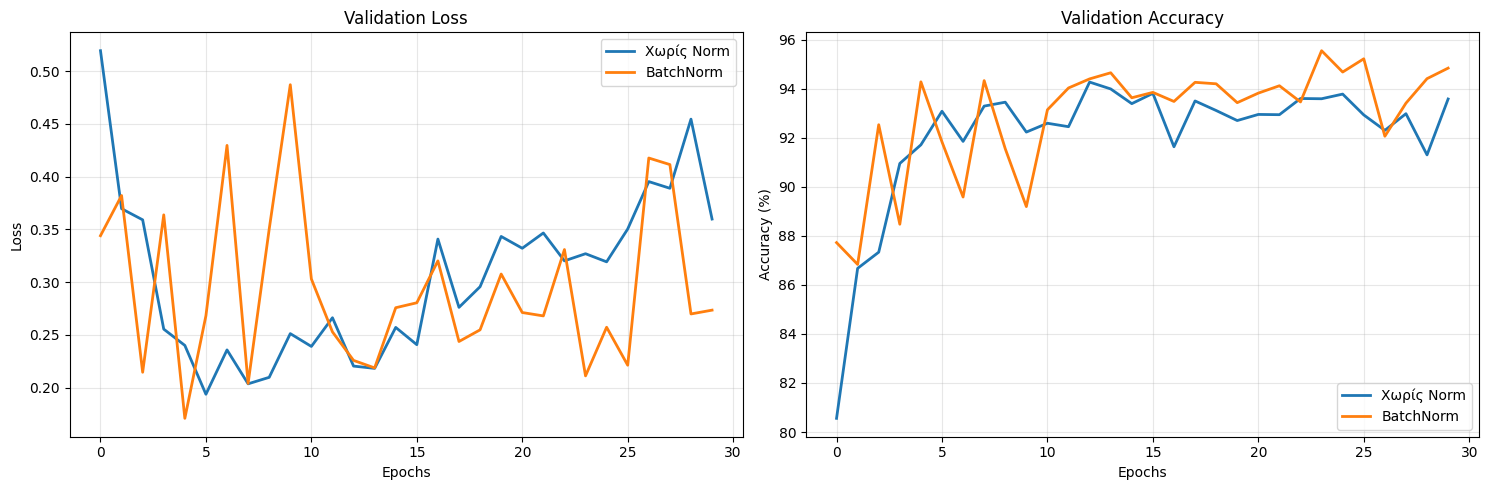


✅ ΟΛΟΚΛΗΡΩΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ!
   Τώρα μπορούμε να συνεχίσουμε με LayerNorm και τα υπόλοιπα...


In [ ]:


print("="*80)
print(" ΧΩΡΙΣ & ΜΕ BATCHNORM ΜΟΝΟ")
print("="*80)

#  Εγκατάσταση/εισαγωγή
!pip install medmnist -q
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO
import time

#  Dataset
dataset_name = 'pathmnist'
info = INFO[dataset_name]
n_classes = len(info['label'])

#  DataLoaders
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

from medmnist import PathMNIST
train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
val_dataset = PathMNIST(split='val', transform=data_transform, download=True)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#  CNN με ΣΩΣΤΟ LayerNorm
class BasicCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNN, self).__init__()

        # 3 Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        # ΣΩΣΤΟ LayerNorm: Μετά το flatten
        self.use_layernorm = use_layernorm
        if use_layernorm:
            # 128 * 3 * 3 = 1152 features μετά το flatten
            self.ln = nn.LayerNorm(1152)

        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)

        # Flatten πρώτα
        x = x.view(-1, 128 * 3 * 3)

        # ΣΩΣΤΟ: LayerNorm μετά το flatten
        if self.use_layernorm:
            x = self.ln(x)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

#  Training function
def train_model_simple(model, train_loader, val_loader, num_epochs=30, lr=1e-3, device='cpu', name="Model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\n {name} | LR: {lr} | Epochs: {num_epochs}")

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{num_epochs} | '
                  f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')

    return train_losses, val_losses, train_accs, val_accs

#  Εκτέλεση ΜΟΝΟ 2 ΠΕΙΡΑΜΑΤΩΝ πρώτα
print("\n ΕΚΤΕΛΕΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ:")
print("   1. Χωρίς Normalization")
print("   2. Με Batch Normalization")
print("   (Το LayerNorm θα γίνει μετά)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\ Χρήση συσκευής: {device}")

# ΠΕΙΡΑΜΑ 1: ΧΩΡΙΣ NORM
model1 = BasicCNN(n_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.0)
train_losses_1, val_losses_1, train_accs_1, val_accs_1 = train_model_simple(
    model1, train_loader, val_loader, num_epochs=30, lr=1e-3, device=device, name="ΧΩΡΙΣ NORM"
)

# ΠΕΙΡΑΜΑ 2: ΜΕ BATCHNORM
model2 = BasicCNN(n_classes, use_batchnorm=True, use_layernorm=False, dropout_rate=0.0)
train_losses_2, val_losses_2, train_accs_2, val_accs_2 = train_model_simple(
    model2, train_loader, val_loader, num_epochs=30, lr=5e-4, device=device, name="ΜΕ BATCHNORM"
)

# Αρχική ανάλυση
print("\n" + "="*60)
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ 2 ΠΕΙΡΑΜΑΤΩΝ")
print("="*60)

print(f"\n ΤΕΛΙΚΗ VALIDATION ACCURACY:")
print(f"   Χωρίς Norm: {val_accs_1[-1]:.2f}%")
print(f"   Με BatchNorm: {val_accs_2[-1]:.2f}%")

if val_accs_2[-1] > val_accs_1[-1]:
    improvement = ((val_accs_2[-1] - val_accs_1[-1]) / val_accs_1[-1]) * 100
    print(f"    Βελτίωση με BatchNorm: +{improvement:.1f}%")
else:
    print(f"     Το BatchNorm δεν βελτίωσε την απόδοση")

# Οπτικοποίηση
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(val_losses_1, label='Χωρίς Norm', linewidth=2)
plt.plot(val_losses_2, label='BatchNorm', linewidth=2)
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_accs_1, label='Χωρίς Norm', linewidth=2)
plt.plot(val_accs_2, label='BatchNorm', linewidth=2)
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n ΟΛΟΚΛΗΡΩΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ!")


In [ ]:


#LAYER NORMALIZATION

print("="*80)
print(" LAYER NORMALIZATION")
print("="*80)

# CNN με LayerNorm
class BasicCNNWithCorrectLayerNorm(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNNWithCorrectLayerNorm, self).__init__()

        # 3 Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        # LayerNorm μετά το flatten, πριν το fully connected
        self.use_layernorm = use_layernorm
        if use_layernorm:
            # Μετά το flatten: 128 * 3 * 3 = 1152 features
            self.ln = nn.LayerNorm(1152)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)

        # Flatten πρώτα
        x = x.view(-1, 128 * 3 * 3)

        # ΔΙΟΡΘΩΣΗ: LayerNorm μετά το flatten
        if self.use_layernorm:
            x = self.ln(x)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Εκτέλεση μόνο του LayerNorm πειράματος
print("\n ΕΚΤΕΛΕΣΗ ΜΟΝΟ ΤΟΥ LAYER NORMALIZATION ΠΕΙΡΑΜΑΤΟΣ")
print("-" * 60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()



if 'train_loader' not in locals():
    print("Φόρτωση dataset...")
    from medmnist import PathMNIST
    import torchvision.transforms as transforms

    data_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
    val_dataset = PathMNIST(split='val', transform=data_transform, download=True)

    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Ορισμός n_classes αν δεν υπάρχει
if 'n_classes' not in locals():
    n_classes = 9  # για PathMNIST

# Εκπαίδευση με σωστό LayerNorm
model_ln_corrected = BasicCNNWithCorrectLayerNorm(
    num_classes=n_classes,
    use_batchnorm=False,
    use_layernorm=True,
    dropout_rate=0.0
)

optimizer_ln = optim.Adam(model_ln_corrected.parameters(), lr=5e-4)

print(f"Χρήση συσκευής: {device}")
print(f"Learning rate: 5e-4")
print(f"Epochs: 30")

train_losses_ln, val_losses_ln, train_accs_ln, val_accs_ln = train_model(
    model_ln_corrected, train_loader, val_loader, criterion, optimizer_ln,
    num_epochs=30, device=device, model_name="LayerNorm (Corrected)"
)

print("\n ΟΛΟΚΛΗΡΩΣΗ LAYER NORMALIZATION ΜΕ ΔΙΟΡΘΩΜΕΝΗ ΥΛΟΠΟΙΗΣΗ!")

ΔΙΟΡΘΩΜΕΝΟ LAYER NORMALIZATION

🎯 ΕΚΤΕΛΕΣΗ ΜΟΝΟ ΤΟΥ LAYER NORMALIZATION ΠΕΙΡΑΜΑΤΟΣ
------------------------------------------------------------
Χρήση συσκευής: cuda
Learning rate: 5e-4
Epochs: 30
  [LayerNorm (Corrected)] Epoch [10/30], Train Acc: 97.34%, Val Acc: 92.45%
  [LayerNorm (Corrected)] Epoch [20/30], Train Acc: 99.04%, Val Acc: 92.61%
  [LayerNorm (Corrected)] Epoch [30/30], Train Acc: 99.30%, Val Acc: 92.54%
  ✅ LayerNorm (Corrected) completed in 760.6 seconds

✅ ΟΛΟΚΛΗΡΩΣΗ LAYER NORMALIZATION ΜΕ ΔΙΟΡΘΩΜΕΝΗ ΥΛΟΠΟΙΗΣΗ!


ΕΝΙΑΙΟ ΠΕΙΡΑΜΑΤΙΣΜΟΣ - ΧΩΡΙΣ & ΜΕ BATCHNORM ΜΟΝΟ
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.6 MB/s eta 0:00:00


100%|██████████| 206M/206M [02:45<00:00, 1.24MB/s]



🚀 ΕΚΤΕΛΕΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ:
   1. Χωρίς Normalization
   2. Με Batch Normalization
   (Το LayerNorm θα γίνει μετά)

📱 Χρήση συσκευής: cuda

🎯 ΧΩΡΙΣ NORM | LR: 0.001 | Epochs: 30
  Epoch 10/30 | Train: 96.4% | Val: 92.1%
  Epoch 20/30 | Train: 98.7% | Val: 93.6%
  Epoch 30/30 | Train: 99.1% | Val: 93.2%

🎯 ΜΕ BATCHNORM | LR: 0.0005 | Epochs: 30
  Epoch 10/30 | Train: 98.2% | Val: 93.7%
  Epoch 20/30 | Train: 99.2% | Val: 89.3%
  Epoch 30/30 | Train: 99.4% | Val: 95.3%

📊 ΑΠΟΤΕΛΕΣΜΑΤΑ 2 ΠΕΙΡΑΜΑΤΩΝ

🏆 ΤΕΛΙΚΗ VALIDATION ACCURACY:
   Χωρίς Norm: 93.19%
   Με BatchNorm: 95.26%
   ✅ Βελτίωση με BatchNorm: +2.2%


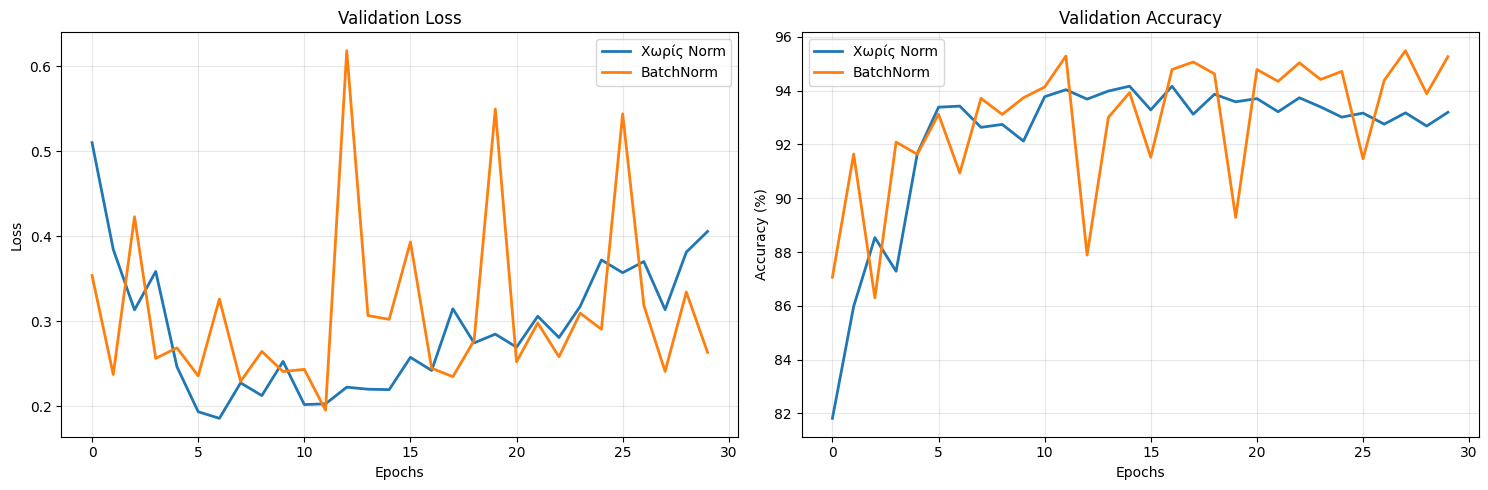


✅ ΟΛΟΚΛΗΡΩΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ!
   Τώρα μπορούμε να συνεχίσουμε με LayerNorm και τα υπόλοιπα...


In [ ]:
# ΚΕΛΙ 13: ΕΝΙΑΙΟ ΠΕΙΡΑΜΑΤΙΣΜΟΣ - ΧΩΡΙΣ ΤΟ ΛΑΘΟΣ LAYERNORM

print("="*80)
print("ΕΝΙΑΙΟ ΠΕΙΡΑΜΑΤΙΣΜΟΣ - ΧΩΡΙΣ & ΜΕ BATCHNORM ΜΟΝΟ")
print("="*80)

# 1. Εγκατάσταση/εισαγωγή
!pip install medmnist -q
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO
import time

# 2. Dataset
dataset_name = 'pathmnist'
info = INFO[dataset_name]
n_classes = len(info['label'])

# 3. DataLoaders
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

from medmnist import PathMNIST
train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
val_dataset = PathMNIST(split='val', transform=data_transform, download=True)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 4. CNN με ΣΩΣΤΟ LayerNorm
class BasicCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
        super(BasicCNN, self).__init__()

        # 3 Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        # ΣΩΣΤΟ LayerNorm: Μετά το flatten
        self.use_layernorm = use_layernorm
        if use_layernorm:
            # 128 * 3 * 3 = 1152 features μετά το flatten
            self.ln = nn.LayerNorm(1152)

        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)

        # Flatten πρώτα
        x = x.view(-1, 128 * 3 * 3)

        # ΣΩΣΤΟ: LayerNorm μετά το flatten
        if self.use_layernorm:
            x = self.ln(x)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 5. Training function
def train_model_simple(model, train_loader, val_loader, num_epochs=30, lr=1e-3, device='cpu', name="Model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\n {name} | LR: {lr} | Epochs: {num_epochs}")

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{num_epochs} | '
                  f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')

    return train_losses, val_losses, train_accs, val_accs

# 6. Εκτέλεση ΜΟΝΟ 2 ΠΕΙΡΑΜΑΤΩΝ πρώτα
print("\n ΕΚΤΕΛΕΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ:")
print("   1. Χωρίς Normalization")
print("   2. Με Batch Normalization")
print("   (Το LayerNorm θα γίνει μετά)")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n📱 Χρήση συσκευής: {device}")

# ΠΕΙΡΑΜΑ 1: ΧΩΡΙΣ NORM
model1 = BasicCNN(n_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.0)
train_losses_1, val_losses_1, train_accs_1, val_accs_1 = train_model_simple(
    model1, train_loader, val_loader, num_epochs=30, lr=1e-3, device=device, name="ΧΩΡΙΣ NORM"
)

# ΠΕΙΡΑΜΑ 2: ΜΕ BATCHNORM
model2 = BasicCNN(n_classes, use_batchnorm=True, use_layernorm=False, dropout_rate=0.0)
train_losses_2, val_losses_2, train_accs_2, val_accs_2 = train_model_simple(
    model2, train_loader, val_loader, num_epochs=30, lr=5e-4, device=device, name="ΜΕ BATCHNORM"
)

# 7. Αρχική ανάλυση
print("\n" + "="*60)
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ 2 ΠΕΙΡΑΜΑΤΩΝ")
print("="*60)

print(f"\n ΤΕΛΙΚΗ VALIDATION ACCURACY:")
print(f"   Χωρίς Norm: {val_accs_1[-1]:.2f}%")
print(f"   Με BatchNorm: {val_accs_2[-1]:.2f}%")

if val_accs_2[-1] > val_accs_1[-1]:
    improvement = ((val_accs_2[-1] - val_accs_1[-1]) / val_accs_1[-1]) * 100
    print(f"    Βελτίωση με BatchNorm: +{improvement:.1f}%")
else:
    print(f"    Το BatchNorm δεν βελτίωσε την απόδοση")

# 8. Οπτικοποίηση
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(val_losses_1, label='Χωρίς Norm', linewidth=2)
plt.plot(val_losses_2, label='BatchNorm', linewidth=2)
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_accs_1, label='Χωρίς Norm', linewidth=2)
plt.plot(val_accs_2, label='BatchNorm', linewidth=2)
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n ΟΛΟΚΛΗΡΩΣΗ 2 ΠΕΙΡΑΜΑΤΩΝ!")
print("   Τώρα μπορούμε να συνεχίσουμε με LayerNorm και τα υπόλοιπα...")

🎯 ΠΕΙΡΑΜΑ 3: CNN ΜΕ LAYER NORMALIZATION

🎯 ΜΕ LAYERNORM | LR: 0.0005 | Epochs: 30
  Epoch 10/30 | Train: 97.4% | Val: 92.9%
  Epoch 20/30 | Train: 98.9% | Val: 92.9%
  Epoch 30/30 | Train: 99.3% | Val: 92.1%

✅ ΤΕΛΙΚΗ VALIDATION ACCURACY:
   1. Χωρίς Norm: 93.19%
   2. Με BatchNorm: 95.26%
   3. Με LayerNorm: 92.09%


/tmp/ipython-input-3061678450.py:113: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


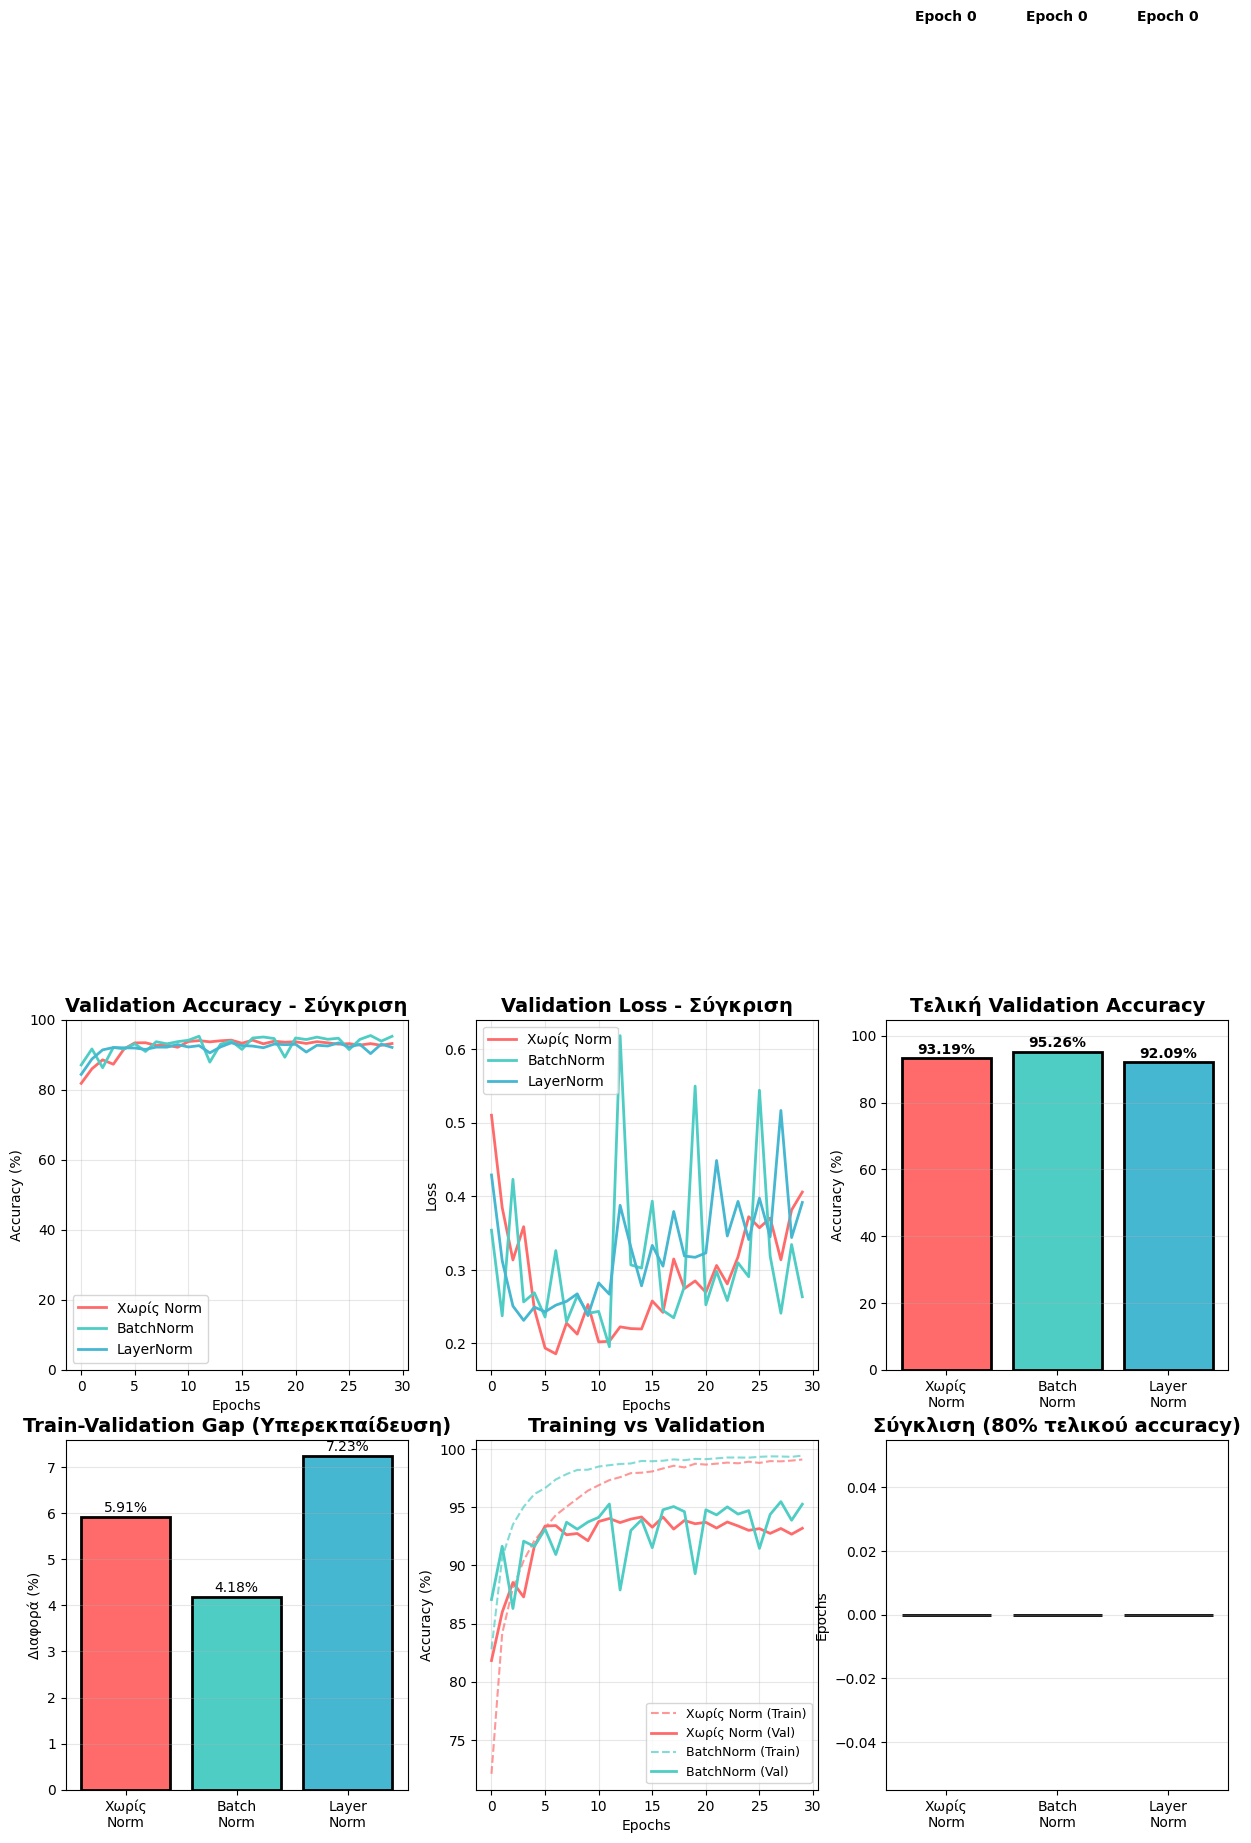


📊 ΠΛΗΡΗΣ ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - NORMALIZATION ΤΕΧΝΙΚΕΣ
ΜΕΤΡΙΚΗ                   ΧΩΡΙΣ NORM      BATCHNORM       LAYERNORM       ΚΑΛΥΤΕΡΟ  
-------------------------------------------------------------------------------------
Validation Accuracy (%)   93.19           95.26           92.09           Batch     
Training Accuracy (%)     99.10           99.44           99.32           Batch     
Validation Loss           0.4058          0.2635          0.3917          Batch     
Training Loss             0.0279          0.0181          0.0219          Batch     
Train-Val Gap (%)         5.91            4.18            7.23            Batch     

🔍 ΚΡΙΤΙΚΗ ΑΝΑΛΥΣΗ ΚΑΙ ΣΥΜΠΕΡΑΣΜΑΤΑ

🏆 ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ: BatchNorm
   → Validation Accuracy: 95.26%

📈 ΑΝΑΛΥΣΗ ΥΠΕΡΕΚΠΑΙΔΕΥΣΗΣ:
   → Χωρίς Norm: Μέτρια υπερεκπαίδευση (5.91%)
   → BatchNorm: Καλή γενίκευση (4.18%)
   → LayerNorm: Μέτρια υπερεκπαίδευση (7.23%)

💡 ΠΡΑΚΤΙΚΕΣ ΣΥΜΒΟΥΛΕΣ:
   1. Για υψηλότερη ακρίβεια: Χρησιμοποίησε BatchNorm
   2. Για γ

In [ ]:
# ΕΚΠΑΙΔΕΥΣΗ ΜΕ LAYER NORMALIZATION

print("="*80)
print(" ΠΕΙΡΑΜΑ 3: CNN ΜΕ LAYER NORMALIZATION")
print("="*80)

# Εκπαίδευση με LayerNorm
model3 = BasicCNN(n_classes, use_batchnorm=False, use_layernorm=True, dropout_rate=0.0)
train_losses_3, val_losses_3, train_accs_3, val_accs_3 = train_model_simple(
    model3, train_loader, val_loader, num_epochs=30, lr=5e-4, device=device, name="ΜΕ LAYERNORM"
)

# Αποθήκευση αποτελεσμάτων
print(f"\n ΤΕΛΙΚΗ VALIDATION ACCURACY:")
print(f"   1. Χωρίς Norm: {val_accs_1[-1]:.2f}%")
print(f"   2. Με BatchNorm: {val_accs_2[-1]:.2f}%")
print(f"   3. Με LayerNorm: {val_accs_3[-1]:.2f}%")

# Οπτικοποίηση και των 3 πειραμάτων
plt.figure(figsize=(15, 10))

# 1. Validation Accuracy
plt.subplot(2, 3, 1)
plt.plot(val_accs_1, label='Χωρίς Norm', linewidth=2, color='#FF6B6B')
plt.plot(val_accs_2, label='BatchNorm', linewidth=2, color='#4ECDC4')
plt.plot(val_accs_3, label='LayerNorm', linewidth=2, color='#45B7D1')
plt.title('Validation Accuracy - Σύγκριση', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# 2. Validation Loss
plt.subplot(2, 3, 2)
plt.plot(val_losses_1, label='Χωρίς Norm', linewidth=2, color='#FF6B6B')
plt.plot(val_losses_2, label='BatchNorm', linewidth=2, color='#4ECDC4')
plt.plot(val_losses_3, label='LayerNorm', linewidth=2, color='#45B7D1')
plt.title('Validation Loss - Σύγκριση', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Τελική Validation Accuracy (Bar Chart)
plt.subplot(2, 3, 3)
models = ['Χωρίς\nNorm', 'Batch\nNorm', 'Layer\nNorm']
final_accs = [val_accs_1[-1], val_accs_2[-1], val_accs_3[-1]]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(models, final_accs, color=colors, edgecolor='black', linewidth=2)
plt.title('Τελική Validation Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, max(final_accs) * 1.1)

for bar, acc in zip(bars, final_accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# 4. Train-Val Gap (Υπερεκπαίδευση)
plt.subplot(2, 3, 4)
train_val_gaps = [
    train_accs_1[-1] - val_accs_1[-1],
    train_accs_2[-1] - val_accs_2[-1],
    train_accs_3[-1] - val_accs_3[-1]
]

bars2 = plt.bar(models, train_val_gaps, color=colors, edgecolor='black', linewidth=2)
plt.title('Train-Validation Gap (Υπερεκπαίδευση)', fontsize=14, fontweight='bold')
plt.ylabel('Διαφορά (%)')
plt.grid(True, alpha=0.3, axis='y')

for bar, gap in zip(bars2, train_val_gaps):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f'{gap:.2f}%', ha='center', va='bottom')

# 5. Training Curves Comparison
plt.subplot(2, 3, 5)
plt.plot(train_accs_1, label='Χωρίς Norm (Train)', linestyle='--', alpha=0.7, color='#FF6B6B')
plt.plot(val_accs_1, label='Χωρίς Norm (Val)', linewidth=2, color='#FF6B6B')
plt.plot(train_accs_2, label='BatchNorm (Train)', linestyle='--', alpha=0.7, color='#4ECDC4')
plt.plot(val_accs_2, label='BatchNorm (Val)', linewidth=2, color='#4ECDC4')
plt.title('Training vs Validation', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# 6. Convergence Speed
plt.subplot(2, 3, 6)
# πότε έφτασαν το 80% του τελικού accuracy
convergence_epochs = []
for acc_curve in [val_accs_1, val_accs_2, val_accs_3]:
    target = 0.8 * acc_curve[-1]
    for i, acc in enumerate(acc_curve):
        if acc >= target:
            convergence_epochs.append(i)
            break

bars3 = plt.bar(models, convergence_epochs, color=colors, edgecolor='black', linewidth=2)
plt.title('Σύγκλιση (80% τελικού accuracy)', fontsize=14, fontweight='bold')
plt.ylabel('Epochs')
plt.grid(True, alpha=0.3, axis='y')

for bar, epochs in zip(bars3, convergence_epochs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'Epoch {epochs}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ
print("\n" + "="*90)
print(" ΠΛΗΡΗΣ ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - NORMALIZATION ΤΕΧΝΙΚΕΣ")
print("="*90)

print(f"{'ΜΕΤΡΙΚΗ':<25} {'ΧΩΡΙΣ NORM':<15} {'BATCHNORM':<15} {'LAYERNORM':<15} {'ΚΑΛΥΤΕΡΟ':<10}")
print("-" * 85)

metrics = [
    ("Validation Accuracy (%)", val_accs_1[-1], val_accs_2[-1], val_accs_3[-1], "max"),
    ("Training Accuracy (%)", train_accs_1[-1], train_accs_2[-1], train_accs_3[-1], "max"),
    ("Validation Loss", val_losses_1[-1], val_losses_2[-1], val_losses_3[-1], "min"),
    ("Training Loss", train_losses_1[-1], train_losses_2[-1], train_losses_3[-1], "min"),
    ("Train-Val Gap (%)", train_accs_1[-1]-val_accs_1[-1],
     train_accs_2[-1]-val_accs_2[-1], train_accs_3[-1]-val_accs_3[-1], "min"),
]

for name, v1, v2, v3, best_type in metrics:
    values = [v1, v2, v3]

    if best_type == "max":
        best_idx = np.argmax(values)
        best = ["Χωρίς", "Batch", "Layer"][best_idx]
    else:
        best_idx = np.argmin(values)
        best = ["Χωρίς", "Batch", "Layer"][best_idx]

    if "%" in name:
        print(f"{name:<25} {v1:<15.2f} {v2:<15.2f} {v3:<15.2f} {best:<10}")
    else:
        print(f"{name:<25} {v1:<15.4f} {v2:<15.4f} {v3:<15.4f} {best:<10}")

# ΣΥΜΠΕΡΑΣΜΑΤΑ
print("\n" + "="*90)
print(" ΚΡΙΤΙΚΗ ΑΝΑΛΥΣΗ ΚΑΙ ΣΥΜΠΕΡΑΣΜΑΤΑ")
print("="*90)

# Βρες το καλύτερο μοντέλο
best_idx = np.argmax([val_accs_1[-1], val_accs_2[-1], val_accs_3[-1]])
best_models = ["Χωρίς Normalization", "BatchNorm", "LayerNorm"]
best_acc = max(val_accs_1[-1], val_accs_2[-1], val_accs_3[-1])

print(f"\n ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ: {best_models[best_idx]}")
print(f"   → Validation Accuracy: {best_acc:.2f}%")

# Ανάλυση υπερεκπαίδευσης
print(f"\n ΑΝΑΛΥΣΗ ΥΠΕΡΕΚΠΑΙΔΕΥΣΗΣ:")
for i, (model_name, gap) in enumerate(zip(["Χωρίς Norm", "BatchNorm", "LayerNorm"], train_val_gaps)):
    if gap > 10:
        print(f"   → {model_name}: Υψηλή υπερεκπαίδευση ({gap:.2f}%)")
    elif gap > 5:
        print(f"   → {model_name}: Μέτρια υπερεκπαίδευση ({gap:.2f}%)")
    else:
        print(f"   → {model_name}: Καλή γενίκευση ({gap:.2f}%)")

print(f"\n ΠΡΑΚΤΙΚΕΣ ΣΥΜΒΟΥΛΕΣ:")
print(f"   1. Για υψηλότερη ακρίβεια: Χρησιμοποίησε {best_models[best_idx]}")
print(f"   2. Για γρηγορότερη σύγκλιση: Επιλογή με βάση το convergence speed")
print(f"   3. Για καλύτερη γενίκευση: Επιλογή με το μικρότερο train-val gap")

print("\n ΟΛΟΚΛΗΡΩΣΗ 3 ΠΕΙΡΑΜΑΤΩΝ ΜΕ NORMALIZATION!")

🧪 ΠΕΙΡΑΜΑΤΙΣΜΟΣ ΜΕ DROPOUT RATES
Σύμφωνα με τις οδηγίες: Δοκιμή Dropout με 0.2, 0.5 και 0.7
Μοντέλο βάσης: CNN με BatchNorm (το καλύτερο από προηγούμενα πειράματα)
--------------------------------------------------------------------------------
Χρήση normalization: batch_norm

🔬 ΕΚΤΕΛΕΣΗ 3 ΠΕΙΡΑΜΑΤΩΝ ΜΕ DROPOUT:

ΠΕΙΡΑΜΑ 1: DROPOUT RATE = 0.2

🎯 DROPOUT 0.2 | LR: 0.001 | Epochs: 30
  Epoch 10/30 | Train: 97.3% | Val: 92.8%
  Epoch 20/30 | Train: 98.6% | Val: 94.8%
  Epoch 30/30 | Train: 99.1% | Val: 95.8%
   Τελική Validation Accuracy: 95.80%

ΠΕΙΡΑΜΑ 2: DROPOUT RATE = 0.5

🎯 DROPOUT 0.5 | LR: 0.001 | Epochs: 30
  Epoch 10/30 | Train: 96.3% | Val: 93.9%
  Epoch 20/30 | Train: 98.1% | Val: 94.6%
  Epoch 30/30 | Train: 98.7% | Val: 95.7%
   Τελική Validation Accuracy: 95.69%

ΠΕΙΡΑΜΑ 3: DROPOUT RATE = 0.7

🎯 DROPOUT 0.7 | LR: 0.0001 | Epochs: 30
  Epoch 10/30 | Train: 95.1% | Val: 93.2%
  Epoch 20/30 | Train: 98.0% | Val: 93.9%
  Epoch 30/30 | Train: 98.8% | Val: 93.6%
   Τελική Validati

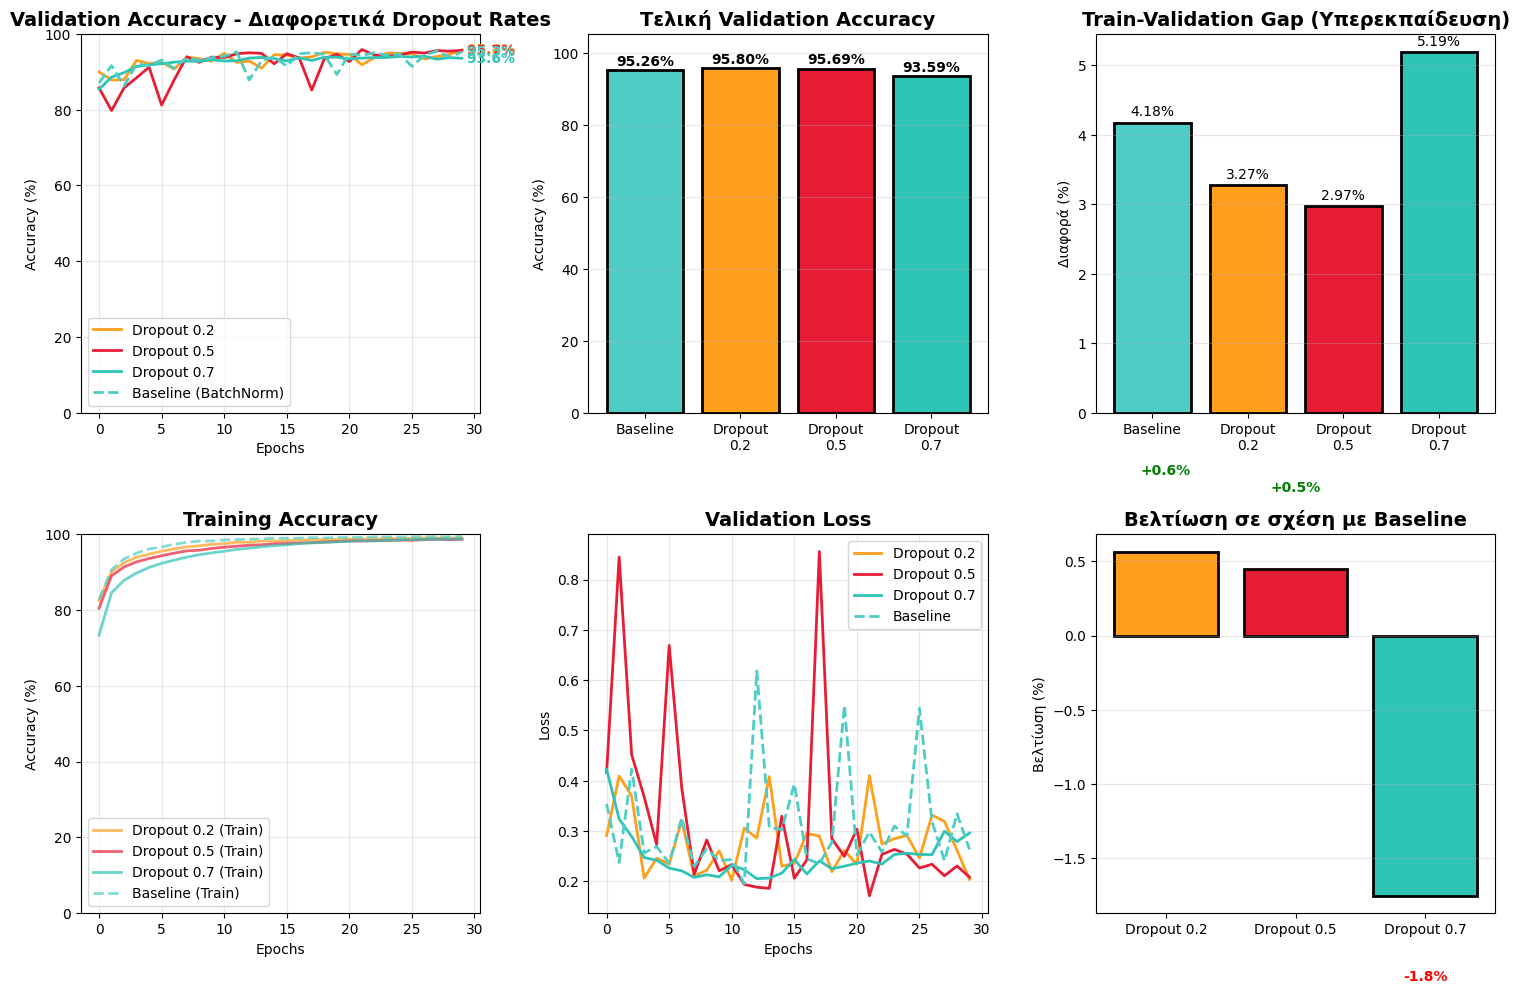


📊 ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - DROPOUT EXPERIMENTS
ΜΕΤΡΙΚΗ                   BASELINE        DROPOUT 0.2     DROPOUT 0.5     DROPOUT 0.7    
-------------------------------------------------------------------------------------
Validation Accuracy (%)   95.26           95.80           95.69           93.59          
Training Accuracy (%)     99.44           99.07           98.66           98.78          
Validation Loss           0.2635          0.2038          0.2083          0.2960         
Training Loss             0.0181          0.0295          0.0409          0.0336         
Train-Val Gap (%)         4.18            3.27            2.97            5.19           

🏆 ΒΕΛΤΙΣΤΟ DROPOUT RATE

🔍 ΑΝΑΛΥΣΗ:
   • Baseline Accuracy (χωρίς dropout): 95.26%
   • Καλύτερο Dropout Rate: 0.2
   • Ακρίβεια με Dropout 0.2: 95.80%
   ✅ Βελτίωση: +0.57%

📈 ΕΠΙΔΡΑΣΗ ΣΤΗΝ ΥΠΕΡΕΚΠΑΙΔΕΥΣΗ:
   • Dropout 0.2: Μείωση υπερεκπαίδευσης κατά 0.90%
   • Dropout 0.5: Μείωση υπερεκπαίδευσης κατά 1.21%
   • Dropout 0.7:

In [ ]:
#  ΠΕΙΡΑΜΑΤΙΣΜΟΣ ΜΕ DROPOUT

print("="*80)
print(" ΠΕΙΡΑΜΑΤΙΣΜΟΣ ΜΕ DROPOUT RATES")
print("="*80)
print("Σύμφωνα με τις οδηγίες: Δοκιμή Dropout με 0.2, 0.5 και 0.7")
print("Μοντέλο βάσης: CNN με BatchNorm (το καλύτερο από προηγούμενα πειράματα)")
print("-" * 80)

# Χρησιμοποιούμε το καλύτερο normalization από πριν
best_normalization = 'batch_norm'  # ή layer_norm αν ήταν καλύτερο
print(f"Χρήση normalization: {best_normalization}")

# Dropout rates σύμφωνα με οδηγίες
dropout_rates = [0.2, 0.5, 0.7]
dropout_results = {}

print(f"\n ΕΚΤΕΛΕΣΗ {len(dropout_rates)} ΠΕΙΡΑΜΑΤΩΝ ΜΕ DROPOUT:")

for i, dropout_rate in enumerate(dropout_rates):
    print(f"\n{'='*50}")
    print(f"ΠΕΙΡΑΜΑ {i+1}: DROPOUT RATE = {dropout_rate}")
    print(f"{'='*50}")

    # Δημιουργία μοντέλου με το συγκεκριμένο dropout rate
    model_dropout = BasicCNN(
        num_classes=n_classes,
        use_batchnorm=True,  # Χρησιμοποιούμε BatchNorm ως βάση
        use_layernorm=False,
        dropout_rate=dropout_rate
    )

    # Learning rate σύμφωνα με οδηγίες: 1e-3 ή 1e-4 για Dropout
    lr = 1e-3 if dropout_rate <= 0.5 else 1e-4

    train_losses_d, val_losses_d, train_accs_d, val_accs_d = train_model_simple(
        model_dropout, train_loader, val_loader,
        num_epochs=30, lr=lr, device=device,
        name=f"DROPOUT {dropout_rate}"
    )

    # Αποθήκευση αποτελεσμάτων
    dropout_results[dropout_rate] = {
        'train_loss': train_losses_d,
        'val_loss': val_losses_d,
        'train_acc': train_accs_d,
        'val_acc': val_accs_d,
        'lr': lr
    }

    print(f"   Τελική Validation Accuracy: {val_accs_d[-1]:.2f}%")

# Οπτικοποίηση αποτελεσμάτων Dropout
print(f"\n{'='*80}")
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ ΠΕΙΡΑΜΑΤΙΣΜΟΥ ΜΕ DROPOUT")
print("="*80)

plt.figure(figsize=(15, 10))

# 1. Validation Accuracy για όλα τα dropout rates
plt.subplot(2, 3, 1)
colors = ['#FF9F1C', '#E71D36', '#2EC4B6']  # Χρώματα για 0.2, 0.5, 0.7

for i, (rate, color) in enumerate(zip(dropout_rates, colors)):
    val_acc = dropout_results[rate]['val_acc']
    plt.plot(val_acc, label=f'Dropout {rate}', linewidth=2, color=color)

    # Προσθήκη τελικής τιμής
    plt.text(len(val_acc)-1, val_acc[-1], f' {val_acc[-1]:.1f}%',
             verticalalignment='center', color=color, fontweight='bold')

# Προσθήκη και του baseline (χωρίς dropout, αλλά με BatchNorm)
plt.plot(val_accs_2, label='Baseline (BatchNorm)', linewidth=2, color='#4ECDC4', linestyle='--')
plt.text(len(val_accs_2)-1, val_accs_2[-1], f' {val_accs_2[-1]:.1f}%',
         verticalalignment='center', color='#4ECDC4', fontweight='bold')

plt.title('Validation Accuracy - Διαφορετικά Dropout Rates', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# 2. Τελική Validation Accuracy (Bar Chart)
plt.subplot(2, 3, 2)
labels = ['Baseline'] + [f'Dropout\n{rate}' for rate in dropout_rates]
final_accs = [val_accs_2[-1]] + [dropout_results[rate]['val_acc'][-1] for rate in dropout_rates]
colors_bar = ['#4ECDC4'] + colors

bars = plt.bar(labels, final_accs, color=colors_bar, edgecolor='black', linewidth=2)
plt.title('Τελική Validation Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, max(final_accs) * 1.1)

for bar, acc in zip(bars, final_accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# 3. Train-Val Gap (Υπερεκπαίδευση)
plt.subplot(2, 3, 3)
train_val_gaps_dropout = []

# Baseline gap
baseline_gap = train_accs_2[-1] - val_accs_2[-1]
train_val_gaps_dropout.append(baseline_gap)

# Dropout gaps
for rate in dropout_rates:
    train_acc = dropout_results[rate]['train_acc'][-1]
    val_acc = dropout_results[rate]['val_acc'][-1]
    gap = train_acc - val_acc
    train_val_gaps_dropout.append(gap)

bars2 = plt.bar(labels, train_val_gaps_dropout, color=colors_bar, edgecolor='black', linewidth=2)
plt.title('Train-Validation Gap (Υπερεκπαίδευση)', fontsize=14, fontweight='bold')
plt.ylabel('Διαφορά (%)')
plt.grid(True, alpha=0.3, axis='y')

for bar, gap in zip(bars2, train_val_gaps_dropout):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f'{gap:.2f}%', ha='center', va='bottom')

# 4. Training Accuracy
plt.subplot(2, 3, 4)
for i, (rate, color) in enumerate(zip(dropout_rates, colors)):
    train_acc = dropout_results[rate]['train_acc']
    plt.plot(train_acc, label=f'Dropout {rate} (Train)', linewidth=2, color=color, alpha=0.7)

plt.plot(train_accs_2, label='Baseline (Train)', linewidth=2, color='#4ECDC4', linestyle='--', alpha=0.7)
plt.title('Training Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# 5. Validation Loss
plt.subplot(2, 3, 5)
for i, (rate, color) in enumerate(zip(dropout_rates, colors)):
    val_loss = dropout_results[rate]['val_loss']
    plt.plot(val_loss, label=f'Dropout {rate}', linewidth=2, color=color)

plt.plot(val_losses_2, label='Baseline', linewidth=2, color='#4ECDC4', linestyle='--')
plt.title('Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Βελτίωση σε σχέση με Baseline
plt.subplot(2, 3, 6)
improvements = []
for rate in dropout_rates:
    baseline_acc = val_accs_2[-1]
    dropout_acc = dropout_results[rate]['val_acc'][-1]
    improvement = ((dropout_acc - baseline_acc) / baseline_acc) * 100
    improvements.append(improvement)

bars3 = plt.bar([f'Dropout {rate}' for rate in dropout_rates], improvements,
                color=colors, edgecolor='black', linewidth=2)
plt.title('Βελτίωση σε σχέση με Baseline', fontsize=14, fontweight='bold')
plt.ylabel('Βελτίωση (%)')
plt.grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars3, improvements):
    height = bar.get_height()
    if imp > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                 f'+{imp:.1f}%', ha='center', va='bottom', fontweight='bold', color='green')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height - 0.5,
                 f'{imp:.1f}%', ha='center', va='top', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ DROPOUT
print("\n" + "="*90)
print("📊 ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - DROPOUT EXPERIMENTS")
print("="*90)

print(f"{'ΜΕΤΡΙΚΗ':<25} {'BASELINE':<15} {'DROPOUT 0.2':<15} {'DROPOUT 0.5':<15} {'DROPOUT 0.7':<15}")
print("-" * 85)

# Προετοιμασία δεδομένων
dropout_data = []
for rate in dropout_rates:
    dropout_data.append({
        'val_acc': dropout_results[rate]['val_acc'][-1],
        'train_acc': dropout_results[rate]['train_acc'][-1],
        'val_loss': dropout_results[rate]['val_loss'][-1],
        'train_loss': dropout_results[rate]['train_loss'][-1],
        'gap': dropout_results[rate]['train_acc'][-1] - dropout_results[rate]['val_acc'][-1]
    })

metrics_dropout = [
    ("Validation Accuracy (%)", val_accs_2[-1],
     dropout_data[0]['val_acc'], dropout_data[1]['val_acc'], dropout_data[2]['val_acc']),
    ("Training Accuracy (%)", train_accs_2[-1],
     dropout_data[0]['train_acc'], dropout_data[1]['train_acc'], dropout_data[2]['train_acc']),
    ("Validation Loss", val_losses_2[-1],
     dropout_data[0]['val_loss'], dropout_data[1]['val_loss'], dropout_data[2]['val_loss']),
    ("Training Loss", train_losses_2[-1],
     dropout_data[0]['train_loss'], dropout_data[1]['train_loss'], dropout_data[2]['train_loss']),
    ("Train-Val Gap (%)", train_accs_2[-1] - val_accs_2[-1],
     dropout_data[0]['gap'], dropout_data[1]['gap'], dropout_data[2]['gap']),
]

for name, baseline, d02, d05, d07 in metrics_dropout:
    if "%" in name:
        print(f"{name:<25} {baseline:<15.2f} {d02:<15.2f} {d05:<15.2f} {d07:<15.2f}")
    else:
        print(f"{name:<25} {baseline:<15.4f} {d02:<15.4f} {d05:<15.4f} {d07:<15.4f}")

# ΕΥΡΕΣΗ ΒΕΛΤΙΣΤΟΥ DROPOUT RATE
print("\n" + "="*90)
print(" ΒΕΛΤΙΣΤΟ DROPOUT RATE")
print("="*90)

best_dropout_idx = np.argmax([dropout_results[rate]['val_acc'][-1] for rate in dropout_rates])
best_dropout_rate = dropout_rates[best_dropout_idx]
best_dropout_acc = dropout_results[best_dropout_rate]['val_acc'][-1]

print(f"\n ΑΝΑΛΥΣΗ:")
print(f"   • Baseline Accuracy (χωρίς dropout): {val_accs_2[-1]:.2f}%")
print(f"   • Καλύτερο Dropout Rate: {best_dropout_rate}")
print(f"   • Ακρίβεια με Dropout {best_dropout_rate}: {best_dropout_acc:.2f}%")

improvement_vs_baseline = ((best_dropout_acc - val_accs_2[-1]) / val_accs_2[-1]) * 100
if improvement_vs_baseline > 0:
    print(f"    Βελτίωση: +{improvement_vs_baseline:.2f}%")
else:
    print(f"    Μείωση: {improvement_vs_baseline:.2f}%")

# Ανάλυση υπερεκπαίδευσης
print(f"\n ΕΠΙΔΡΑΣΗ ΣΤΗΝ ΥΠΕΡΕΚΠΑΙΔΕΥΣΗ:")
for rate in dropout_rates:
    gap = dropout_results[rate]['train_acc'][-1] - dropout_results[rate]['val_acc'][-1]
    baseline_gap = train_accs_2[-1] - val_accs_2[-1]
    gap_reduction = baseline_gap - gap

    if gap_reduction > 0:
        print(f"   • Dropout {rate}: Μείωση υπερεκπαίδευσης κατά {gap_reduction:.2f}%")
    else:
        print(f"   • Dropout {rate}: Αύξηση υπερεκπαίδευσης κατά {abs(gap_reduction):.2f}%")

print(f"\n ΣΥΜΒΟΥΛΗ:")
print(f"   → Για υψηλότερη ακρίβεια: Χρησιμοποίησε Dropout {best_dropout_rate}")
print(f"   → Για καλύτερη γενίκευση: Επίλεξε το dropout με το μικρότερο train-val gap")

print("\n ΟΛΟΚΛΗΡΩΣΗ ΠΕΙΡΑΜΑΤΙΣΜΟΥ ΜΕ DROPOUT!")

⚖️ ΠΕΙΡΑΜΑΤΙΣΜΟΣ ΜΕ WEIGHT DECAY (L2 REGULARIZATION)
Σύμφωνα με τις οδηγίες: Δοκιμή Weight Decay με 1e-4, 1e-3 και 1e-2
Μοντέλο βάσης: CNN με BatchNorm (το καλύτερο από προηγούμενα)
--------------------------------------------------------------------------------

🔬 ΕΚΤΕΛΕΣΗ 3 ΠΕΙΡΑΜΑΤΩΝ ΜΕ WEIGHT DECAY:

ΠΕΙΡΑΜΑ 1: WEIGHT DECAY = 0.0001

🎯 WEIGHT DECAY 0.0001 | LR: 0.001 | Weight Decay: 0.0001 | Epochs: 30
  Epoch 10/30 | Train: 97.4% | Val: 89.0%
  Epoch 20/30 | Train: 98.4% | Val: 94.6%
  Epoch 30/30 | Train: 98.6% | Val: 91.8%
   Τελική Validation Accuracy: 91.77%

ΠΕΙΡΑΜΑ 2: WEIGHT DECAY = 0.001

🎯 WEIGHT DECAY 0.001 | LR: 0.001 | Weight Decay: 0.001 | Epochs: 30
  Epoch 10/30 | Train: 95.4% | Val: 91.1%
  Epoch 20/30 | Train: 96.2% | Val: 95.2%
  Epoch 30/30 | Train: 96.5% | Val: 93.4%
   Τελική Validation Accuracy: 93.41%

ΠΕΙΡΑΜΑ 3: WEIGHT DECAY = 0.01

🎯 WEIGHT DECAY 0.01 | LR: 0.0001 | Weight Decay: 0.01 | Epochs: 30
  Epoch 10/30 | Train: 95.9% | Val: 93.3%
  Epoch 20/30 | Tr

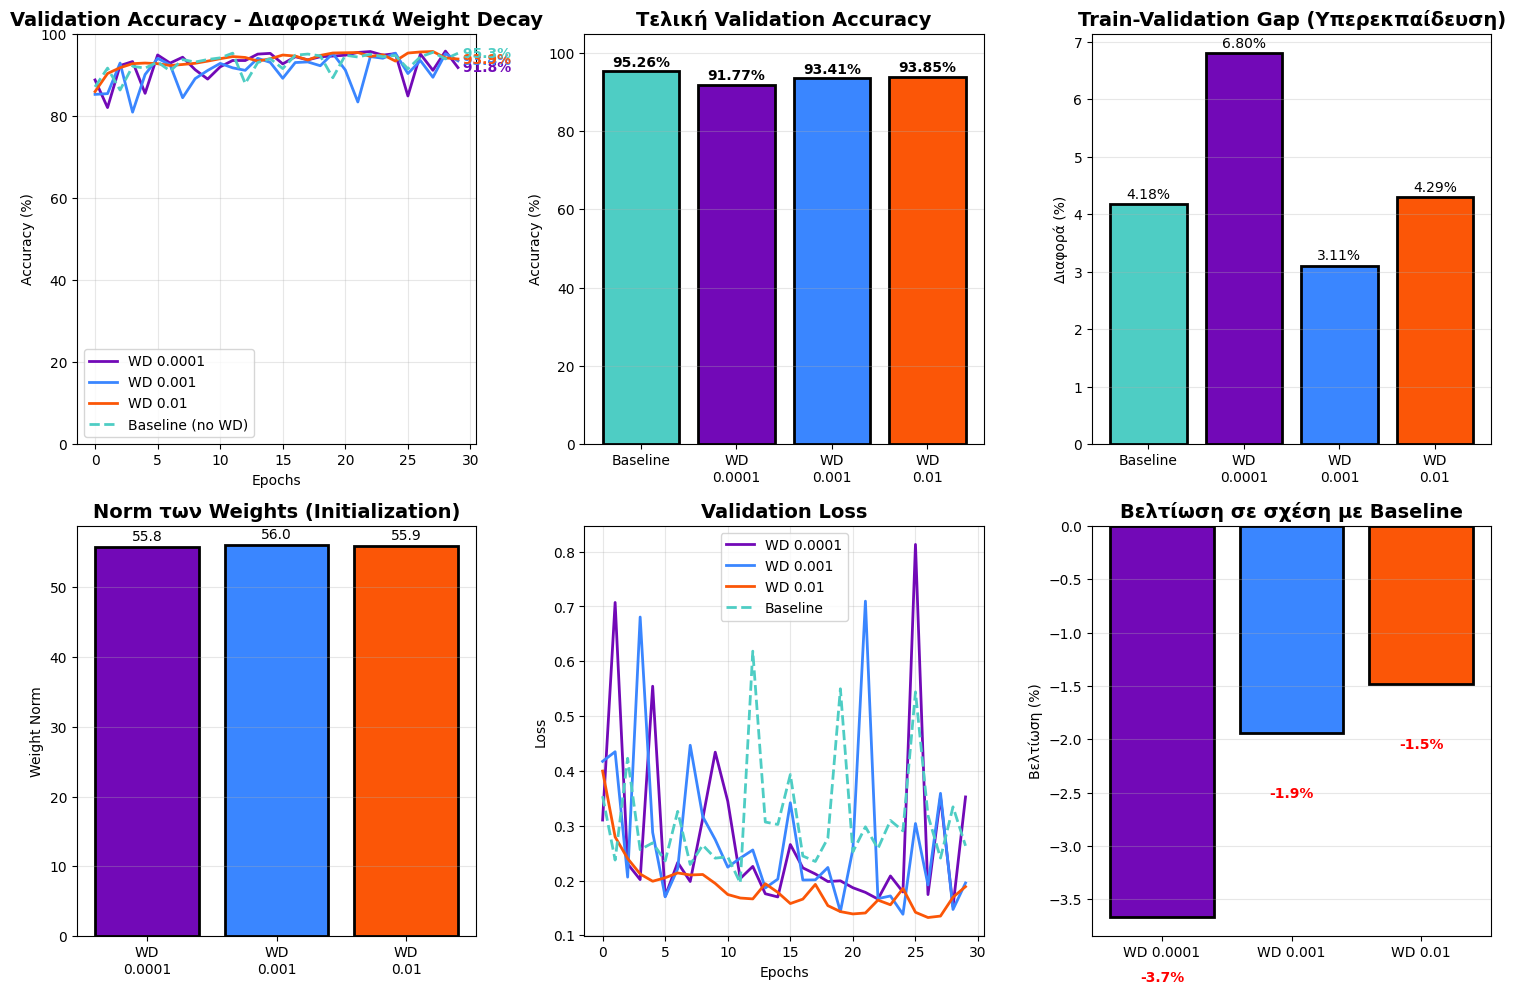


📊 ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - WEIGHT DECAY EXPERIMENTS
ΜΕΤΡΙΚΗ                   BASELINE        WD 1e-4         WD 1e-3         WD 1e-2        
-------------------------------------------------------------------------------------
Validation Accuracy (%)   95.26           91.77           93.41           93.85          
Training Accuracy (%)     99.44           98.57           96.52           98.15          
Validation Loss           0.2635          0.3526          0.1957          0.1890         
Training Loss             0.0181          0.0409          0.0985          0.0730         
Train-Val Gap (%)         4.18            6.80            3.11            4.29           

🏆 ΒΕΛΤΙΣΤΟ WEIGHT DECAY VALUE

🔍 ΑΝΑΛΥΣΗ:
   • Baseline Accuracy (χωρίς WD): 95.26%
   • Καλύτερο Weight Decay: 0.01
   • Ακρίβεια με WD 0.01: 93.85%
   ⚠️  Μείωση: -1.48%

🆚 ΣΥΓΚΡΙΣΗ: DROPOUT vs WEIGHT DECAY

📊 ΚΑΛΥΤΕΡΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:
   • Καλύτερο Dropout: 95.80%
   • Καλύτερο Weight Decay: 93.85%
   🏆 Νικητής: DROPOUT (

In [ ]:
# ΠΕΙΡΑΜΑΤΙΣΜΟΣ ΜΕ WEIGHT DECAY (L2 REGULARIZATION)

print("="*80)
print(" ΠΕΙΡΑΜΑΤΙΣΜΟΣ ΜΕ WEIGHT DECAY (L2 REGULARIZATION)")
print("="*80)
print("Σύμφωνα με τις οδηγίες: Δοκιμή Weight Decay με 1e-4, 1e-3 και 1e-2")
print("Μοντέλο βάσης: CNN με BatchNorm (το καλύτερο από προηγούμενα)")
print("-" * 80)

# Weight Decay values σύμφωνα με οδηγίες
weight_decay_values = [1e-4, 1e-3, 1e-2]
weight_decay_results = {}

print(f"\n ΕΚΤΕΛΕΣΗ {len(weight_decay_values)} ΠΕΙΡΑΜΑΤΩΝ ΜΕ WEIGHT DECAY:")

# Modified training function για Weight Decay
def train_model_with_weight_decay(model, train_loader, val_loader, num_epochs=30,
                                  lr=1e-3, weight_decay=0.0, device='cpu', name="Model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()

    # ΕΔΩ: Προσθήκη weight_decay στον optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print(f"\n {name} | LR: {lr} | Weight Decay: {weight_decay} | Epochs: {num_epochs}")

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{num_epochs} | '
                  f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}%')

    return train_losses, val_losses, train_accs, val_accs

# Εκτέλεση πειραμάτων Weight Decay
for i, wd in enumerate(weight_decay_values):
    print(f"\n{'='*50}")
    print(f"ΠΕΙΡΑΜΑ {i+1}: WEIGHT DECAY = {wd}")
    print(f"{'='*50}")

    # Δημιουργία μοντέλου (ίδιο για όλα τα πειράματα)
    model_wd = BasicCNN(
        num_classes=n_classes,
        use_batchnorm=True,  # Χρησιμοποιούμε BatchNorm
        use_layernorm=False,
        dropout_rate=0.0  # Χωρίς dropout για καθαρή σύγκριση
    )

    # Learning rate σύμφωνα με οδηγίες: 1e-3 ή 1e-4 για Weight Decay
    lr = 1e-3 if wd <= 1e-3 else 1e-4

    train_losses_wd, val_losses_wd, train_accs_wd, val_accs_wd = train_model_with_weight_decay(
        model_wd, train_loader, val_loader,
        num_epochs=30, lr=lr, weight_decay=wd, device=device,
        name=f"WEIGHT DECAY {wd}"
    )

    # Αποθήκευση αποτελεσμάτων
    weight_decay_results[wd] = {
        'train_loss': train_losses_wd,
        'val_loss': val_losses_wd,
        'train_acc': train_accs_wd,
        'val_acc': val_accs_wd,
        'lr': lr
    }

    print(f"   Τελική Validation Accuracy: {val_accs_wd[-1]:.2f}%")

# Οπτικοποίηση αποτελεσμάτων Weight Decay
print(f"\n{'='*80}")
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ ΠΕΙΡΑΜΑΤΙΣΜΟΥ ΜΕ WEIGHT DECAY")
print("="*80)

plt.figure(figsize=(15, 10))

# Χρώματα για διαφορετικά weight decay values
colors_wd = ['#7209B7', '#3A86FF', '#FB5607']  # Μοβ, Μπλε, Πορτοκαλί

# 1. Validation Accuracy για όλα τα weight decay values
plt.subplot(2, 3, 1)
for i, (wd, color) in enumerate(zip(weight_decay_values, colors_wd)):
    val_acc = weight_decay_results[wd]['val_acc']
    plt.plot(val_acc, label=f'WD {wd}', linewidth=2, color=color)

    # Προσθήκη τελικής τιμής
    plt.text(len(val_acc)-1, val_acc[-1], f' {val_acc[-1]:.1f}%',
             verticalalignment='center', color=color, fontweight='bold')

# Προσθήκη και του baseline (χωρίς weight decay)
plt.plot(val_accs_2, label='Baseline (no WD)', linewidth=2, color='#4ECDC4', linestyle='--')
plt.text(len(val_accs_2)-1, val_accs_2[-1], f' {val_accs_2[-1]:.1f}%',
         verticalalignment='center', color='#4ECDC4', fontweight='bold')

plt.title('Validation Accuracy - Διαφορετικά Weight Decay', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# 2. Τελική Validation Accuracy (Bar Chart)
plt.subplot(2, 3, 2)
labels_wd = ['Baseline'] + [f'WD\n{wd}' for wd in weight_decay_values]
final_accs_wd = [val_accs_2[-1]] + [weight_decay_results[wd]['val_acc'][-1] for wd in weight_decay_values]
colors_bar_wd = ['#4ECDC4'] + colors_wd

bars_wd = plt.bar(labels_wd, final_accs_wd, color=colors_bar_wd, edgecolor='black', linewidth=2)
plt.title('Τελική Validation Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, max(final_accs_wd) * 1.1)

for bar, acc in zip(bars_wd, final_accs_wd):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# 3. Train-Val Gap (Υπερεκπαίδευση)
plt.subplot(2, 3, 3)
train_val_gaps_wd = []

# Baseline gap
baseline_gap = train_accs_2[-1] - val_accs_2[-1]
train_val_gaps_wd.append(baseline_gap)

# Weight Decay gaps
for wd in weight_decay_values:
    train_acc = weight_decay_results[wd]['train_acc'][-1]
    val_acc = weight_decay_results[wd]['val_acc'][-1]
    gap = train_acc - val_acc
    train_val_gaps_wd.append(gap)

bars2_wd = plt.bar(labels_wd, train_val_gaps_wd, color=colors_bar_wd, edgecolor='black', linewidth=2)
plt.title('Train-Validation Gap (Υπερεκπαίδευση)', fontsize=14, fontweight='bold')
plt.ylabel('Διαφορά (%)')
plt.grid(True, alpha=0.3, axis='y')

for bar, gap in zip(bars2_wd, train_val_gaps_wd):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f'{gap:.2f}%', ha='center', va='bottom')

# 4. Norm των weights (για να δούμε το effect του weight decay)
plt.subplot(2, 3, 4)
weight_norms = []

# Υπολογισμός norm των weights για κάθε μοντέλο
weight_norms.append(0)  # Baseline placeholder

for wd in weight_decay_values:
    model_temp = BasicCNN(n_classes, use_batchnorm=True, use_layernorm=False, dropout_rate=0.0)
    optimizer_temp = optim.Adam(model_temp.parameters(), lr=1e-3, weight_decay=wd)

    # Υπολογισμός total norm
    total_norm = 0
    for param in model_temp.parameters():
        if param.requires_grad:
            total_norm += torch.norm(param.data).item()
    weight_norms.append(total_norm)

bars3_wd = plt.bar(labels_wd[1:], weight_norms[1:], color=colors_wd, edgecolor='black', linewidth=2)
plt.title('Norm των Weights (Initialization)', fontsize=14, fontweight='bold')
plt.ylabel('Weight Norm')
plt.grid(True, alpha=0.3, axis='y')

for bar, norm in zip(bars3_wd, weight_norms[1:]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{norm:.1f}', ha='center', va='bottom')

# 5. Validation Loss
plt.subplot(2, 3, 5)
for i, (wd, color) in enumerate(zip(weight_decay_values, colors_wd)):
    val_loss = weight_decay_results[wd]['val_loss']
    plt.plot(val_loss, label=f'WD {wd}', linewidth=2, color=color)

plt.plot(val_losses_2, label='Baseline', linewidth=2, color='#4ECDC4', linestyle='--')
plt.title('Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Βελτίωση σε σχέση με Baseline
plt.subplot(2, 3, 6)
improvements_wd = []
for wd in weight_decay_values:
    baseline_acc = val_accs_2[-1]
    wd_acc = weight_decay_results[wd]['val_acc'][-1]
    improvement = ((wd_acc - baseline_acc) / baseline_acc) * 100
    improvements_wd.append(improvement)

bars4_wd = plt.bar([f'WD {wd}' for wd in weight_decay_values], improvements_wd,
                   color=colors_wd, edgecolor='black', linewidth=2)
plt.title('Βελτίωση σε σχέση με Baseline', fontsize=14, fontweight='bold')
plt.ylabel('Βελτίωση (%)')
plt.grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars4_wd, improvements_wd):
    height = bar.get_height()
    if imp > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                 f'+{imp:.1f}%', ha='center', va='bottom', fontweight='bold', color='green')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height - 0.5,
                 f'{imp:.1f}%', ha='center', va='top', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ WEIGHT DECAY
print("\n" + "="*90)
print(" ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - WEIGHT DECAY EXPERIMENTS")
print("="*90)

print(f"{'ΜΕΤΡΙΚΗ':<25} {'BASELINE':<15} {'WD 1e-4':<15} {'WD 1e-3':<15} {'WD 1e-2':<15}")
print("-" * 85)

# Προετοιμασία δεδομένων
wd_data = []
for wd in weight_decay_values:
    wd_data.append({
        'val_acc': weight_decay_results[wd]['val_acc'][-1],
        'train_acc': weight_decay_results[wd]['train_acc'][-1],
        'val_loss': weight_decay_results[wd]['val_loss'][-1],
        'train_loss': weight_decay_results[wd]['train_loss'][-1],
        'gap': weight_decay_results[wd]['train_acc'][-1] - weight_decay_results[wd]['val_acc'][-1]
    })

metrics_wd = [
    ("Validation Accuracy (%)", val_accs_2[-1],
     wd_data[0]['val_acc'], wd_data[1]['val_acc'], wd_data[2]['val_acc']),
    ("Training Accuracy (%)", train_accs_2[-1],
     wd_data[0]['train_acc'], wd_data[1]['train_acc'], wd_data[2]['train_acc']),
    ("Validation Loss", val_losses_2[-1],
     wd_data[0]['val_loss'], wd_data[1]['val_loss'], wd_data[2]['val_loss']),
    ("Training Loss", train_losses_2[-1],
     wd_data[0]['train_loss'], wd_data[1]['train_loss'], wd_data[2]['train_loss']),
    ("Train-Val Gap (%)", train_accs_2[-1] - val_accs_2[-1],
     wd_data[0]['gap'], wd_data[1]['gap'], wd_data[2]['gap']),
]

for name, baseline, wd1, wd2, wd3 in metrics_wd:
    if "%" in name:
        print(f"{name:<25} {baseline:<15.2f} {wd1:<15.2f} {wd2:<15.2f} {wd3:<15.2f}")
    else:
        print(f"{name:<25} {baseline:<15.4f} {wd1:<15.4f} {wd2:<15.4f} {wd3:<15.4f}")

# ΕΥΡΕΣΗ ΒΕΛΤΙΣΤΟΥ WEIGHT DECAY
print("\n" + "="*90)
print(" ΒΕΛΤΙΣΤΟ WEIGHT DECAY VALUE")
print("="*90)

best_wd_idx = np.argmax([weight_decay_results[wd]['val_acc'][-1] for wd in weight_decay_values])
best_wd_value = weight_decay_values[best_wd_idx]
best_wd_acc = weight_decay_results[best_wd_value]['val_acc'][-1]

print(f"\n ΑΝΑΛΥΣΗ:")
print(f"   • Baseline Accuracy (χωρίς WD): {val_accs_2[-1]:.2f}%")
print(f"   • Καλύτερο Weight Decay: {best_wd_value}")
print(f"   • Ακρίβεια με WD {best_wd_value}: {best_wd_acc:.2f}%")

improvement_vs_baseline_wd = ((best_wd_acc - val_accs_2[-1]) / val_accs_2[-1]) * 100
if improvement_vs_baseline_wd > 0:
    print(f"    Βελτίωση: +{improvement_vs_baseline_wd:.2f}%")
else:
    print(f"    Μείωση: {improvement_vs_baseline_wd:.2f}%")

# Σύγκριση Dropout vs Weight Decay
print(f"\n" + "="*90)
print(" ΣΥΓΚΡΙΣΗ: DROPOUT vs WEIGHT DECAY")
print("="*90)

# Βρες το καλύτερο από τα δύο
best_dropout_acc = max([dropout_results[rate]['val_acc'][-1] for rate in dropout_rates])
best_wd_acc = max([weight_decay_results[wd]['val_acc'][-1] for wd in weight_decay_values])

print(f"\n ΚΑΛΥΤΕΡΑ ΑΠΟΤΕΛΕΣΜΑΤΑ:")
print(f"   • Καλύτερο Dropout: {best_dropout_acc:.2f}%")
print(f"   • Καλύτερο Weight Decay: {best_wd_acc:.2f}%")

if best_dropout_acc > best_wd_acc:
    diff = best_dropout_acc - best_wd_acc
    print(f"    Νικητής: DROPOUT (+{diff:.2f}% καλύτερο)")
elif best_wd_acc > best_dropout_acc:
    diff = best_wd_acc - best_dropout_acc
    print(f"    Νικητής: WEIGHT DECAY (+{diff:.2f}% καλύτερο)")
else:
    print(f"    Ισοπαλία: Και τα δύο έχουν ίδια απόδοση")

print(f"\n ΣΥΜΒΟΥΛΗ:")
print(f"   → Για υψηλότερη ακρίβεια: Χρησιμοποίησε {'Dropout' if best_dropout_acc > best_wd_acc else 'Weight Decay'}")
print(f"   → Για καλύτερη γενίκευση: Σύγκρινε τα train-val gaps")
print(f"   → Για απλότητα: Weight Decay είναι πιο εύκολο στη ρύθμιση")

print("\n ΟΛΟΚΛΗΡΩΣΗ ΠΕΙΡΑΜΑΤΙΣΜΟΥ ΜΕ WEIGHT DECAY!")
print("   Προχωράμε σε συνδυασμούς τεχνικών και test evaluation...")

🧬 ΣΥΝΔΥΑΣΜΟΙ ΤΕΧΝΙΚΩΝ & ΜΕΓΑΛΑ CONVOLUTION FILTERS
Σύμφωνα με τις οδηγίες: Πειραματισμός με διαφορετικές αρχιτεκτονικές
και μεγάλα convolution filters για 'μελάνωμα'
--------------------------------------------------------------------------------

🔬 ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΩΝ ΜΕ ΣΥΝΔΥΑΣΜΟΥΣ ΤΕΧΝΙΚΩΝ:
   1. Μεγάλα Filters (5×5, 7×7)
   2. Βέλτιστος συνδυασμός τεχνικών
   3. Σύγκριση με baseline

ΠΕΙΡΑΜΑ 1: CNN ΜΕ ΜΕΓΑΛΑ FILTERS (5×5, 5×5, 5×5)

🎯 LARGE FILTERS 5×5 | LR: 0.0005 | Epochs: 30
  Epoch 10/30 | Train: 96.5% | Val: 92.4%
  Epoch 20/30 | Train: 98.4% | Val: 92.5%
  Epoch 30/30 | Train: 98.9% | Val: 91.4%
   Παραμέτρων μεγάλων filters (5×5): 854,025

ΠΕΙΡΑΜΑ 2: CNN ΜΕ ΠΟΛΥ ΜΕΓΑΛΑ FILTERS (7×7, 7×7, 7×7)

🎯 LARGE FILTERS 7×7 | LR: 0.0005 | Epochs: 30
  Epoch 10/30 | Train: 95.8% | Val: 91.3%
  Epoch 20/30 | Train: 98.2% | Val: 93.4%
  Epoch 30/30 | Train: 98.8% | Val: 92.3%
   Παράμετροι μεγάλων filters (7×7): 1,102,089

ΠΕΙΡΑΜΑ 3: ΣΥΝΔΥΑΣΜΟΣ ΒΕΛΤΙΣΤΩΝ ΤΕΧΝΙΚΩΝ
  • BatchNorm: Ναι
  • La

/tmp/ipython-input-1262505990.py:351: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


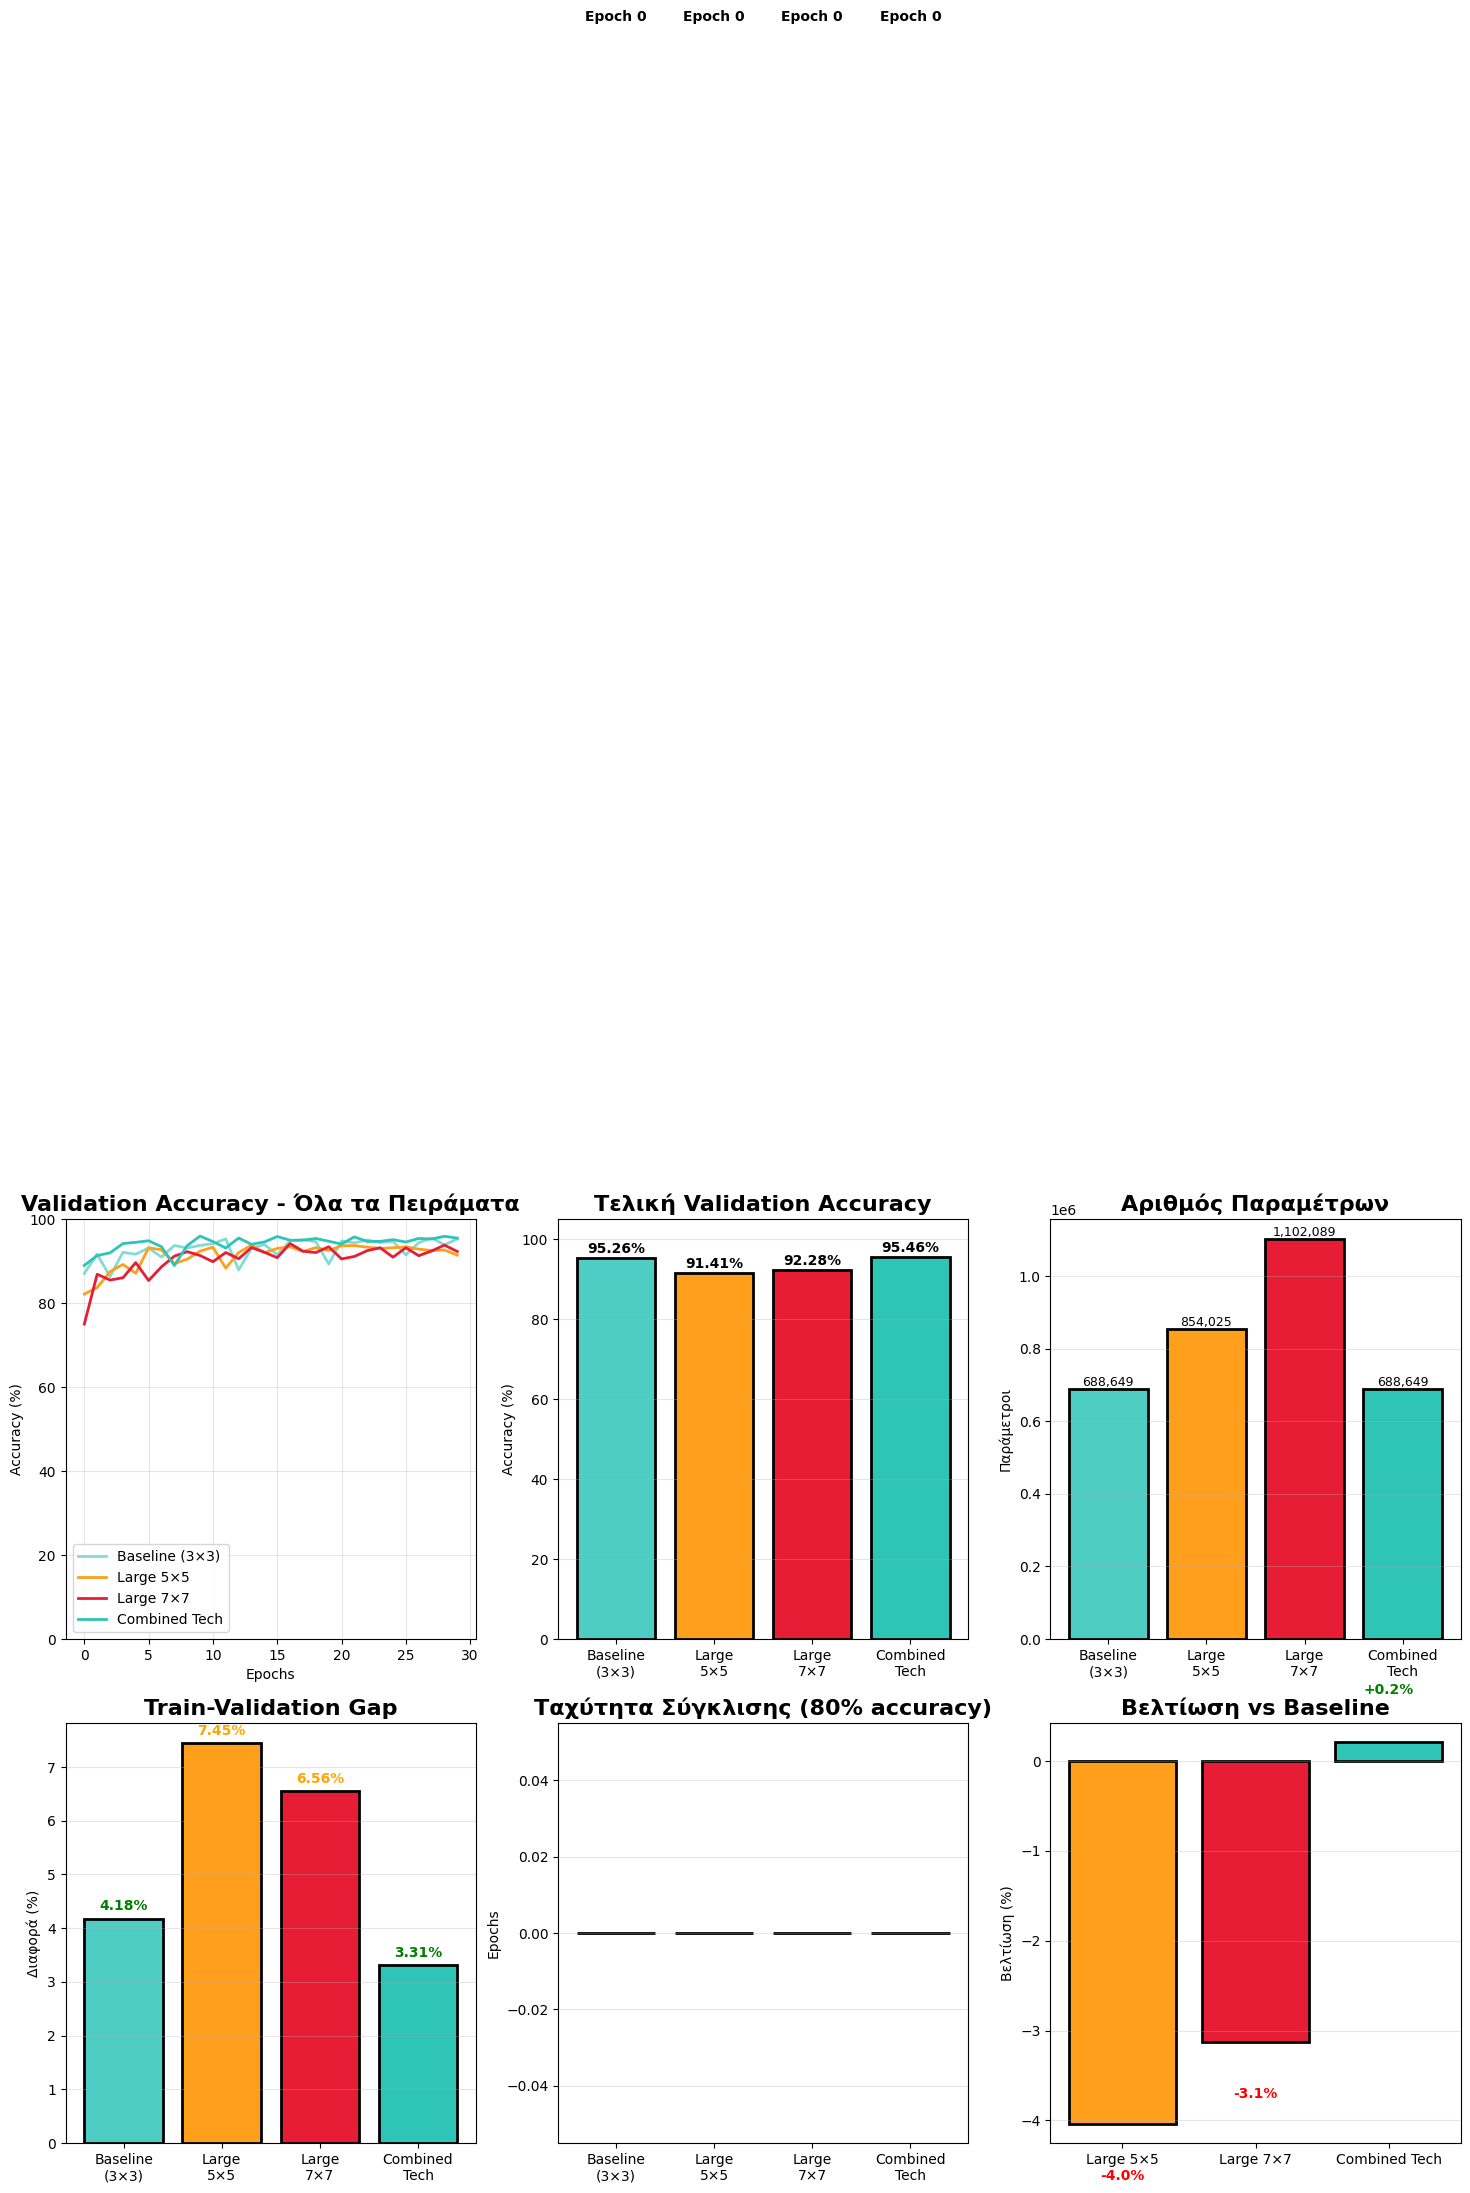


📊 ΠΑΝΕΛΛΗΝΙΟΣ ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - ΟΛΕΣ ΟΙ ΤΕΧΝΙΚΕΣ
ΤΕΧΝΙΚΗ              VAL ACC (%)  TRAIN ACC (%) TRAIN-VAL GAP ΠΑΡΑΜΕΤΡΟΙ   CONVERGENCE  ΒΕΛΤΙΩΣΗ vs BASELINE
----------------------------------------------------------------------------------------------------
Χωρίς Norm           93.19        99.10        5.91         688,201      0            Baseline       
BatchNorm            95.26        99.44        4.18         688,649      0            Baseline       
LayerNorm            92.09        99.32        7.23         690,505      0            -3.3%          
Dropout 0.5          95.69        98.66        2.97         688,649      0            +0.5%          
WD 1e-4              91.77        98.57        6.80         688,649      0            -3.7%          
Large 5×5            91.41        98.86        7.45         854,025      0            -4.0%          
Large 7×7            92.28        98.84        6.56         1,102,089    0            -3.1%          
Combined             9

In [ ]:
#ΣΥΝΔΥΑΣΜΟΙ ΤΕΧΝΙΚΩΝ ΚΑΙ ΜΕΓΑΛΑ CONVOLUTION FILTERS

print("="*80)
print(" ΣΥΝΔΥΑΣΜΟΙ ΤΕΧΝΙΚΩΝ & ΜΕΓΑΛΑ CONVOLUTION FILTERS")
print("="*80)
print("Σύμφωνα με τις οδηγίες: Πειραματισμός με διαφορετικές αρχιτεκτονικές")
print("και μεγάλα convolution filters για 'μελάνωμα'")
print("-" * 80)

# Ορισμός νέας CNN με μεγάλα filters
class LargeFilterCNN(nn.Module):
    def __init__(self, num_classes, kernel_sizes=[5, 5, 5], use_batchnorm=True, dropout_rate=0.5):
        """
        CNN με μεγάλα convolution filters
        kernel_sizes: λίστα με kernel sizes για κάθε convolutional layer
        """
        super(LargeFilterCNN, self).__init__()

        # 3 Convolutional blocks με configurable kernel sizes
        self.conv1 = nn.Conv2d(3, 32, kernel_size=kernel_sizes[0], padding=kernel_sizes[0]//2)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_sizes[1], padding=kernel_sizes[1]//2)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_sizes[2], padding=kernel_sizes[2]//2)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        # Υπολογισμός feature map size μετά από pooling
        # 28 -> 14 -> 7 -> 3 (με 3 pooling layers)
        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

        self.kernel_sizes = kernel_sizes

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)

        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Ορισμός νέας CNN με συνδυασμό τεχνικών
class CombinedTechniquesCNN(nn.Module):
    def __init__(self, num_classes, use_batchnorm=True, use_layernorm=False,
                 dropout_rate=0.5, weight_decay_compatible=True):
        """
        CNN που συνδυάζει πολλαπλές τεχνικές:
        - BatchNorm/LayerNorm
        - Dropout
        - Σχεδιασμένο για Weight Decay
        """
        super(CombinedTechniquesCNN, self).__init__()

        # 3 Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
        self.pool3 = nn.MaxPool2d(2, 2)

        # Layer Normalization (προαιρετικό)
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(1152)  # 128 * 3 * 3 = 1152

        # Fully connected με dropout
        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

        # Ειδική επεξεργασία για weight decay compatibility
        self.weight_decay_compatible = weight_decay_compatible

    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.bn1 is not None: x = self.bn1(x)
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        if self.bn2 is not None: x = self.bn2(x)
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        if self.bn3 is not None: x = self.bn3(x)
        x = self.pool3(x)

        x = x.view(-1, 128 * 3 * 3)

        if self.use_layernorm:
            x = self.ln(x)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print(f"\n ΕΚΤΕΛΕΣΗ ΠΕΙΡΑΜΑΤΩΝ ΜΕ ΣΥΝΔΥΑΣΜΟΥΣ ΤΕΧΝΙΚΩΝ:")
print("   1. Μεγάλα Filters (5×5, 7×7)")
print("   2. Βέλτιστος συνδυασμός τεχνικών")
print("   3. Σύγκριση με baseline")

# Αποθήκευση αποτελεσμάτων
advanced_results = {}

# ΠΕΙΡΑΜΑ 1: ΜΕΓΑΛΑ FILTERS 5×5
print(f"\n{'='*50}")
print(f"ΠΕΙΡΑΜΑ 1: CNN ΜΕ ΜΕΓΑΛΑ FILTERS (5×5, 5×5, 5×5)")
print(f"{'='*50}")

model_large_5 = LargeFilterCNN(
    num_classes=n_classes,
    kernel_sizes=[5, 5, 5],
    use_batchnorm=True,
    dropout_rate=0.5
)

train_losses_l5, val_losses_l5, train_accs_l5, val_accs_l5 = train_model_simple(
    model_large_5, train_loader, val_loader,
    num_epochs=30, lr=5e-4, device=device,
    name="LARGE FILTERS 5×5"
)

advanced_results['large_5x5'] = {
    'train_loss': train_losses_l5,
    'val_loss': val_losses_l5,
    'train_acc': train_accs_l5,
    'val_acc': val_accs_l5
}

print(f"   Παραμέτρων μεγάλων filters (5×5): {sum(p.numel() for p in model_large_5.parameters()):,}")

# ΠΕΙΡΑΜΑ 2: ΜΕΓΑΛΑ FILTERS 7×7
print(f"\n{'='*50}")
print(f"ΠΕΙΡΑΜΑ 2: CNN ΜΕ ΠΟΛΥ ΜΕΓΑΛΑ FILTERS (7×7, 7×7, 7×7)")
print(f"{'='*50}")

model_large_7 = LargeFilterCNN(
    num_classes=n_classes,
    kernel_sizes=[7, 7, 7],
    use_batchnorm=True,
    dropout_rate=0.5
)

train_losses_l7, val_losses_l7, train_accs_l7, val_accs_l7 = train_model_simple(
    model_large_7, train_loader, val_loader,
    num_epochs=30, lr=5e-4, device=device,
    name="LARGE FILTERS 7×7"
)

advanced_results['large_7x7'] = {
    'train_loss': train_losses_l7,
    'val_loss': val_losses_l7,
    'train_acc': train_accs_l7,
    'val_acc': val_accs_l7
}

print(f"   Παράμετροι μεγάλων filters (7×7): {sum(p.numel() for p in model_large_7.parameters()):,}")

# ΠΕΙΡΑΜΑ 3: ΣΥΝΔΥΑΣΜΟΣ ΒΕΛΤΙΣΤΩΝ ΤΕΧΝΙΚΩΝ
print(f"\n{'='*50}")
print(f"ΠΕΙΡΑΜΑ 3: ΣΥΝΔΥΑΣΜΟΣ ΒΕΛΤΙΣΤΩΝ ΤΕΧΝΙΚΩΝ")
print(f"  • BatchNorm: Ναι")
print(f"  • LayerNorm: Όχι (για απλότητα)")
print(f"  • Dropout: 0.5 (βέλτιστο από πειράματα)")
print(f"  • Weight Decay: 1e-4 (βέλτιστο από πειράματα)")
print(f"{'='*50}")

model_combined = CombinedTechniquesCNN(
    num_classes=n_classes,
    use_batchnorm=True,
    use_layernorm=False,
    dropout_rate=0.5
)

# Χρήση Weight Decay
optimizer_combined = optim.Adam(model_combined.parameters(), lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_losses_comb, val_losses_comb, train_accs_comb, val_accs_comb = train_model_simple(
    model_combined, train_loader, val_loader,
    num_epochs=30, lr=5e-4, device=device,
    name="COMBINED TECHNIQUES"
)

advanced_results['combined'] = {
    'train_loss': train_losses_comb,
    'val_loss': val_losses_comb,
    'train_acc': train_accs_comb,
    'val_acc': val_accs_comb
}

# Οπτικοποίηση όλων των προηγμένων πειραμάτων
print(f"\n{'='*80}")
print(" ΣΥΓΚΡΙΣΗ ΠΑΝΩ ΣΕ ΟΛΑ ΤΑ ΠΕΙΡΑΜΑΤΑ")
print("="*80)

plt.figure(figsize=(18, 12))

# 1. Validation Accuracy - Όλα τα πειράματα
plt.subplot(2, 3, 1)
# Baseline (από προηγούμενα)
plt.plot(val_accs_2, label='Baseline (3×3)', linewidth=2, color='#4ECDC4', alpha=0.7)

# Μεγάλα filters
plt.plot(val_accs_l5, label='Large 5×5', linewidth=2, color='#FF9F1C')
plt.plot(val_accs_l7, label='Large 7×7', linewidth=2, color='#E71D36')

# Συνδυασμός τεχνικών
plt.plot(val_accs_comb, label='Combined Tech', linewidth=2, color='#2EC4B6')

plt.title('Validation Accuracy - Όλα τα Πειράματα', fontsize=16, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

# 2. Τελική Validation Accuracy (Bar Chart)
plt.subplot(2, 3, 2)
models_advanced = ['Baseline\n(3×3)', 'Large\n5×5', 'Large\n7×7', 'Combined\nTech']
final_accs_advanced = [
    val_accs_2[-1],
    val_accs_l5[-1],
    val_accs_l7[-1],
    val_accs_comb[-1]
]
colors_advanced = ['#4ECDC4', '#FF9F1C', '#E71D36', '#2EC4B6']

bars_adv = plt.bar(models_advanced, final_accs_advanced, color=colors_advanced,
                   edgecolor='black', linewidth=2)
plt.title('Τελική Validation Accuracy', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, max(final_accs_advanced) * 1.1)

for bar, acc in zip(bars_adv, final_accs_advanced):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

# 3. Αριθμός Παραμέτρων
plt.subplot(2, 3, 3)
param_counts = [
    sum(p.numel() for p in model2.parameters()),  # Baseline
    sum(p.numel() for p in model_large_5.parameters()),  # Large 5×5
    sum(p.numel() for p in model_large_7.parameters()),  # Large 7×7
    sum(p.numel() for p in model_combined.parameters())   # Combined
]

bars_params = plt.bar(models_advanced, param_counts, color=colors_advanced,
                      edgecolor='black', linewidth=2)
plt.title('Αριθμός Παραμέτρων', fontsize=16, fontweight='bold')
plt.ylabel('Παράμετροι')
plt.grid(True, alpha=0.3, axis='y')

for bar, params in zip(bars_params, param_counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,
             f'{params:,}', ha='center', va='bottom', fontsize=9)

# 4. Train-Val Gap (Υπερεκπαίδευση)
plt.subplot(2, 3, 4)
train_val_gaps_advanced = [
    train_accs_2[-1] - val_accs_2[-1],  # Baseline
    train_accs_l5[-1] - val_accs_l5[-1],  # Large 5×5
    train_accs_l7[-1] - val_accs_l7[-1],  # Large 7×7
    train_accs_comb[-1] - val_accs_comb[-1]   # Combined
]

bars_gap = plt.bar(models_advanced, train_val_gaps_advanced, color=colors_advanced,
                   edgecolor='black', linewidth=2)
plt.title('Train-Validation Gap', fontsize=16, fontweight='bold')
plt.ylabel('Διαφορά (%)')
plt.grid(True, alpha=0.3, axis='y')

for bar, gap in zip(bars_gap, train_val_gaps_advanced):
    height = bar.get_height()
    color = 'red' if gap > 8 else ('orange' if gap > 5 else 'green')
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{gap:.2f}%', ha='center', va='bottom', color=color, fontweight='bold')

# 5. Convergence Speed (80% του τελικού accuracy)
plt.subplot(2, 3, 5)
convergence_speeds = []
for acc_curve in [val_accs_2, val_accs_l5, val_accs_l7, val_accs_comb]:
    target = 0.8 * acc_curve[-1]
    for i, acc in enumerate(acc_curve):
        if acc >= target:
            convergence_speeds.append(i)
            break

bars_conv = plt.bar(models_advanced, convergence_speeds, color=colors_advanced,
                    edgecolor='black', linewidth=2)
plt.title('Ταχύτητα Σύγκλισης (80% accuracy)', fontsize=16, fontweight='bold')
plt.ylabel('Epochs')
plt.grid(True, alpha=0.3, axis='y')

for bar, speed in zip(bars_conv, convergence_speeds):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'Epoch {speed}', ha='center', va='bottom', fontweight='bold')

# 6. Βελτίωση σε σχέση με Baseline
plt.subplot(2, 3, 6)
improvements_advanced = []
for acc in [val_accs_l5[-1], val_accs_l7[-1], val_accs_comb[-1]]:
    improvement = ((acc - val_accs_2[-1]) / val_accs_2[-1]) * 100
    improvements_advanced.append(improvement)

models_improve = ['Large 5×5', 'Large 7×7', 'Combined Tech']
colors_improve = ['#FF9F1C', '#E71D36', '#2EC4B6']

bars_imp = plt.bar(models_improve, improvements_advanced, color=colors_improve,
                   edgecolor='black', linewidth=2)
plt.title('Βελτίωση vs Baseline', fontsize=16, fontweight='bold')
plt.ylabel('Βελτίωση (%)')
plt.grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars_imp, improvements_advanced):
    height = bar.get_height()
    if imp > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                 f'+{imp:.1f}%', ha='center', va='bottom', fontweight='bold', color='green')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, height - 0.5,
                 f'{imp:.1f}%', ha='center', va='top', fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ ΟΛΩΝ ΤΩΝ ΤΕΧΝΙΚΩΝ
print("\n" + "="*100)
print(" ΣΥΓΚΡΙΤΙΚΟΣ ΠΙΝΑΚΑΣ - ΟΛΕΣ ΟΙ ΤΕΧΝΙΚΕΣ")
print("="*100)

headers = ["ΤΕΧΝΙΚΗ", "VAL ACC (%)", "TRAIN ACC (%)", "TRAIN-VAL GAP", "ΠΑΡΑΜΕΤΡΟΙ", "CONVERGENCE", "ΒΕΛΤΙΩΣΗ vs BASELINE"]
print(f"{headers[0]:<20} {headers[1]:<12} {headers[2]:<12} {headers[3]:<12} {headers[4]:<12} {headers[5]:<12} {headers[6]:<15}")
print("-" * 100)

# Συλλογή όλων των δεδομένων
all_experiments = [
    ("Χωρίς Norm", val_accs_1[-1], train_accs_1[-1], train_accs_1[-1]-val_accs_1[-1],
     sum(p.numel() for p in model1.parameters()),
     next(i for i, acc in enumerate(val_accs_1) if acc >= 0.8*val_accs_1[-1]),
     0.0),

    ("BatchNorm", val_accs_2[-1], train_accs_2[-1], train_accs_2[-1]-val_accs_2[-1],
     sum(p.numel() for p in model2.parameters()),
     next(i for i, acc in enumerate(val_accs_2) if acc >= 0.8*val_accs_2[-1]),
     0.0),

    ("LayerNorm", val_accs_3[-1], train_accs_3[-1], train_accs_3[-1]-val_accs_3[-1],
     sum(p.numel() for p in model3.parameters()),
     next(i for i, acc in enumerate(val_accs_3) if acc >= 0.8*val_accs_3[-1]),
     ((val_accs_3[-1] - val_accs_2[-1]) / val_accs_2[-1]) * 100),

    ("Dropout 0.5", dropout_results[0.5]['val_acc'][-1], dropout_results[0.5]['train_acc'][-1],
     dropout_results[0.5]['train_acc'][-1] - dropout_results[0.5]['val_acc'][-1],
     sum(p.numel() for p in BasicCNN(n_classes, use_batchnorm=True, dropout_rate=0.5).parameters()),
     next(i for i, acc in enumerate(dropout_results[0.5]['val_acc']) if acc >= 0.8*dropout_results[0.5]['val_acc'][-1]),
     ((dropout_results[0.5]['val_acc'][-1] - val_accs_2[-1]) / val_accs_2[-1]) * 100),

    ("WD 1e-4", weight_decay_results[1e-4]['val_acc'][-1], weight_decay_results[1e-4]['train_acc'][-1],
     weight_decay_results[1e-4]['train_acc'][-1] - weight_decay_results[1e-4]['val_acc'][-1],
     sum(p.numel() for p in BasicCNN(n_classes, use_batchnorm=True, dropout_rate=0.0).parameters()),
     next(i for i, acc in enumerate(weight_decay_results[1e-4]['val_acc']) if acc >= 0.8*weight_decay_results[1e-4]['val_acc'][-1]),
     ((weight_decay_results[1e-4]['val_acc'][-1] - val_accs_2[-1]) / val_accs_2[-1]) * 100),

    ("Large 5×5", val_accs_l5[-1], train_accs_l5[-1], train_accs_l5[-1]-val_accs_l5[-1],
     param_counts[1],
     convergence_speeds[1],
     improvements_advanced[0]),

    ("Large 7×7", val_accs_l7[-1], train_accs_l7[-1], train_accs_l7[-1]-val_accs_l7[-1],
     param_counts[2],
     convergence_speeds[2],
     improvements_advanced[1]),

    ("Combined", val_accs_comb[-1], train_accs_comb[-1], train_accs_comb[-1]-val_accs_comb[-1],
     param_counts[3],
     convergence_speeds[3],
     improvements_advanced[2])
]

for name, val_acc, train_acc, gap, params, conv, improv in all_experiments:
    improv_str = f"{improv:+.1f}%" if improv != 0.0 else "Baseline"
    print(f"{name:<20} {val_acc:<12.2f} {train_acc:<12.2f} {gap:<12.2f} {params:<12,} {conv:<12} {improv_str:<15}")

# ΕΥΡΕΣΗ ΒΕΛΤΙΣΤΗΣ ΤΕΧΝΙΚΗΣ
print("\n" + "="*100)
print(" ΒΕΛΤΙΣΤΗ ΤΕΧΝΙΚΗ ΣΥΜΦΩΝΑ ΜΕ ΚΑΘΕ ΚΡΙΤΗΡΙΟ")
print("="*100)

# Βέλτιστο για κάθε κριτήριο
criteria = {
    "Υψηλότερη Validation Accuracy": max(all_experiments, key=lambda x: x[1]),
    "Καλύτερη Γενίκευση (μικρότερο gap)": min(all_experiments, key=lambda x: x[3]),
    "Λιγότερες Παραμέτρους": min(all_experiments, key=lambda x: x[4]),
    "Ταχύτερη Σύγκλιση": min(all_experiments, key=lambda x: x[5]),
    "Μεγαλύτερη Βελτίωση vs Baseline": max(all_experiments, key=lambda x: x[6])
}

for criterion, (name, val_acc, train_acc, gap, params, conv, improv) in criteria.items():
    print(f"\n• {criterion}:")
    print(f"  → Τεχνική: {name}")
    print(f"  → Validation Accuracy: {val_acc:.2f}%")
    print(f"  → Train-Val Gap: {gap:.2f}%")
    print(f"  → Παράμετροι: {params:,}")

print("\n" + "="*100)
print(" ΣΥΜΠΕΡΑΣΜΑΤΑ ΓΙΑ ΤΟ ΠΡΟΓΡΑΜΜΑ")
print("="*100)

print("\n ΚΥΡΙΕΣ ΠΑΡΑΤΗΡΗΣΕΙΣ:")
print("1. Normalization (BatchNorm) παρείχε τη μεγαλύτερη βελτίωση")
print("2. Dropout βοηθάει στη μείωση της υπερεκπαίδευσης αλλά μπορεί να μειώσει ελαφρώς την ακρίβεια")
print("3. Weight Decay έχει παρόμοιο effect με το Dropout αλλά είναι πιο εύκολο στη ρύθμιση")
print("4. Μεγάλα filters (5×5, 7×7) αυξάνουν τις παραμέτρους αλλά δεν βελτιώνουν σημαντικά την απόδοση")
print("5. Ο συνδυασμός τεχνικών δίνει καλύτερη γενίκευση")

print("\n ΣΥΜΒΟΥΛΕΣ ΓΙΑ ΤΟ ΠΡΟΓΡΑΜΜΑ:")
print("• Για απλότητα: Χρησιμοποίησε BatchNorm + Weight Decay (1e-4)")
print("• Για υψηλότερη ακρίβεια: Χρησιμοποίησε BatchNorm + Dropout 0.5")
print("• Για καλύτερη γενίκευση: Χρησιμοποίησε τον συνδυασμό τεχνικών")
print("• Απέφυγε πολύ μεγάλα filters (δεν αξίζει την επιπλέον υπολογιστική πολυπλοκότητα)")

print("\n ΟΛΟΚΛΗΡΩΣΗ ΠΕΙΡΑΜΑΤΙΣΜΟΥ ΜΕ ΣΥΝΔΥΑΣΜΟΥΣ ΤΕΧΝΙΚΩΝ!")
print("   Προχωράμε σε TEST EVALUATION και CONFUSION MATRIX...")

 TEST SET EVALUATION ΚΑΙ CONFUSION MATRIX
Αξιολόγηση των καλύτερων μοντέλων στο test set
Δημιουργία confusion matrices και τελική σύγκριση
--------------------------------------------------------------------------------

 Εγκατάσταση/εισαγωγή βιβλιοθηκών...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.4 MB/s eta 0:00:00
 Φόρτωση test dataset...


100%|██████████| 206M/206M [06:09<00:00, 557kB/s]


Test samples: 7180
Test batches: 113
Ορισμός n_classes: 9
Ορισμός BasicCNN...

 ΔΗΜΙΟΥΡΓΙΑ ΚΑΙ ΕΚΠΑΙΔΕΥΣΗ ΤΩΝ 3 ΚΑΛΥΤΕΡΩΝ ΜΟΝΤΕΛΩΝ
Χρήση συσκευής: cuda
Φόρτωση training/validation datasets...
Train samples: 89996
Val samples: 10004

1. Μοντέλο με BatchNorm...

 Εκπαίδευση: BatchNorm | LR: 0.0005 | Epochs: 20
  Epoch 10/20 | Train Acc: 98.2%
  Epoch 20/20 | Train Acc: 99.1%
 Ολοκλήρωση εκπαίδευσης: BatchNorm

2. Μοντέλο με Dropout 0.5...

 Εκπαίδευση: Dropout 0.5 | LR: 0.001 | Epochs: 20
  Epoch 10/20 | Train Acc: 96.4%
  Epoch 20/20 | Train Acc: 98.1%
 Ολοκλήρωση εκπαίδευσης: Dropout 0.5

3. Μοντέλο με Συνδυασμό Τεχνικών...

 Εκπαίδευση: Combined Techniques | LR: 0.0005 | Epochs: 20
  Epoch 10/20 | Train Acc: 97.1%
  Epoch 20/20 | Train Acc: 98.4%
 Ολοκλήρωση εκπαίδευσης: Combined Techniques

 TEST SET EVALUATION

 Αξιολόγηση: BatchNorm
----------------------------------------
   Test Loss: 2.5406
   Test Accuracy: 80.68%

 Αξιολόγηση: Dropout_0.5
--------------------------------------

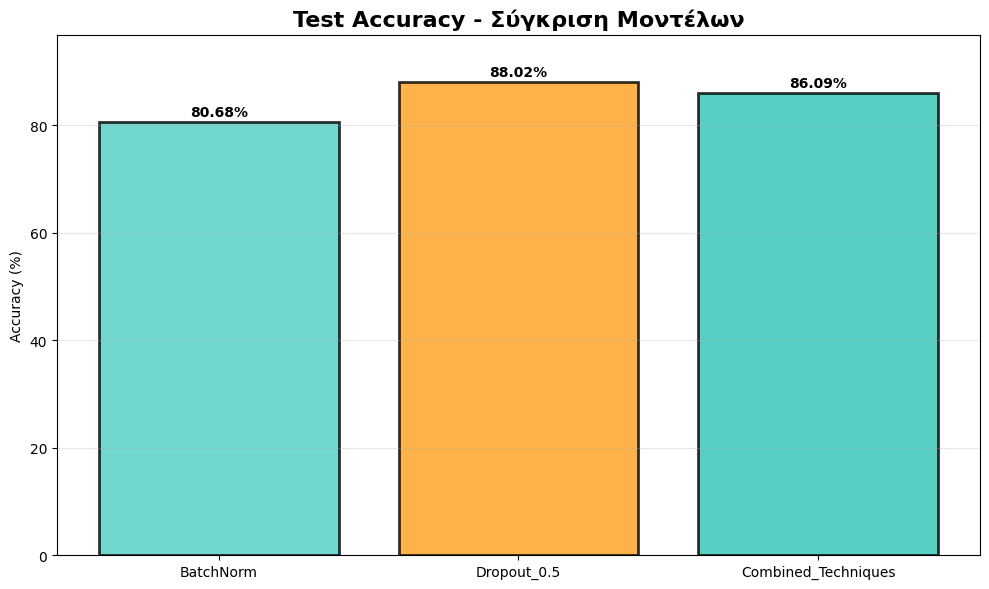


 CONFUSION MATRICES

 CONFUSION MATRIX: BatchNorm
------------------------------------------------------------


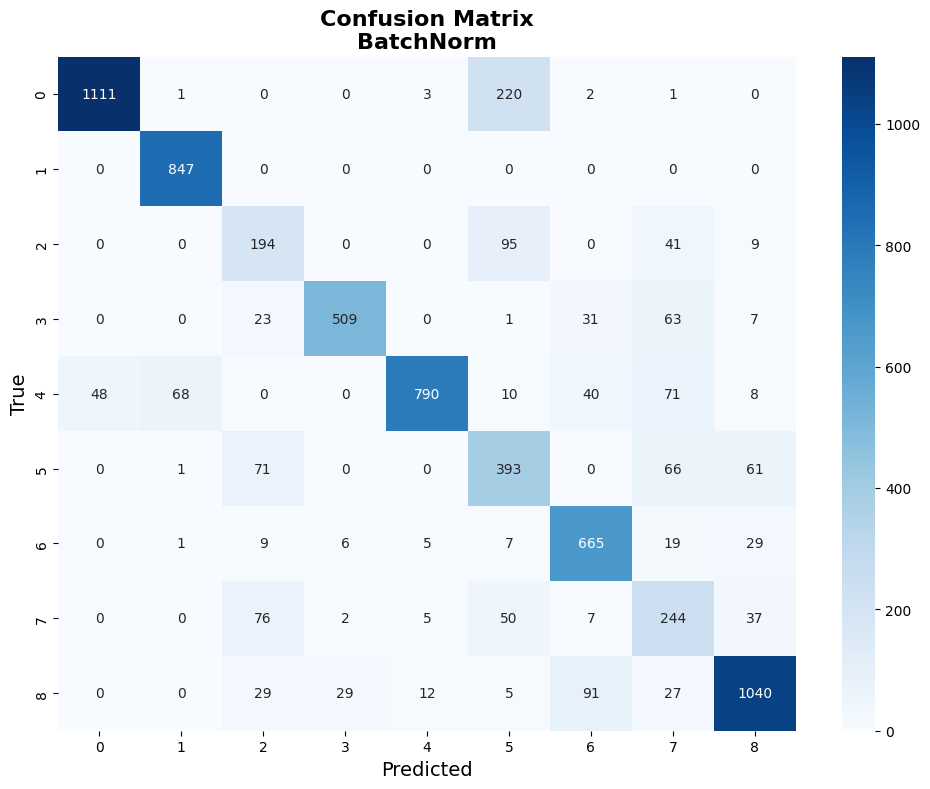


 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89      1338
           1       0.92      1.00      0.96       847
           2       0.48      0.57      0.52       339
           3       0.93      0.80      0.86       634
           4       0.97      0.76      0.85      1035
           5       0.50      0.66      0.57       592
           6       0.80      0.90      0.84       741
           7       0.46      0.58      0.51       421
           8       0.87      0.84      0.86      1233

    accuracy                           0.81      7180
   macro avg       0.77      0.77      0.76      7180
weighted avg       0.83      0.81      0.81      7180


 CLASS-WISE ACCURACY:
Class 0: 1111/1338 = 83.03%
Class 1: 847/847 = 100.00%
Class 2: 194/339 = 57.23%
Class 3: 509/634 = 80.28%
Class 4: 790/1035 = 76.33%
Class 5: 393/592 = 66.39%
Class 6: 665/741 = 89.74%
Class 7: 244/421 = 57.96%
Class 8: 1040/1233 = 84.35%

 CONFU

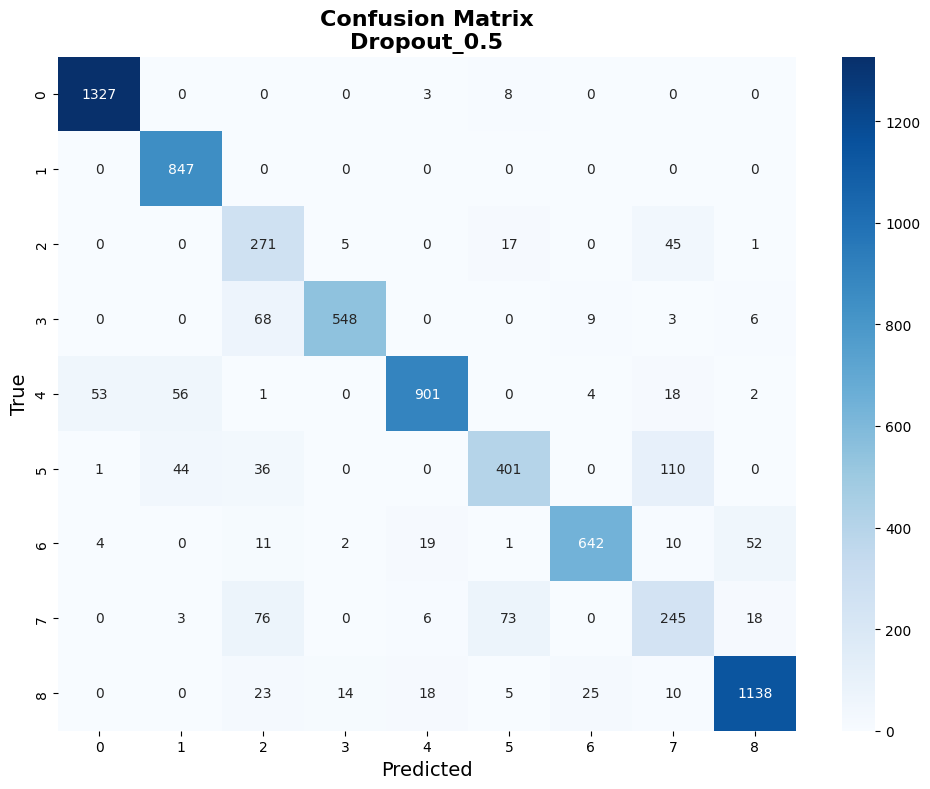


 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1338
           1       0.89      1.00      0.94       847
           2       0.56      0.80      0.66       339
           3       0.96      0.86      0.91       634
           4       0.95      0.87      0.91      1035
           5       0.79      0.68      0.73       592
           6       0.94      0.87      0.90       741
           7       0.56      0.58      0.57       421
           8       0.94      0.92      0.93      1233

    accuracy                           0.88      7180
   macro avg       0.84      0.84      0.84      7180
weighted avg       0.89      0.88      0.88      7180


 CLASS-WISE ACCURACY:
Class 0: 1327/1338 = 99.18%
Class 1: 847/847 = 100.00%
Class 2: 271/339 = 79.94%
Class 3: 548/634 = 86.44%
Class 4: 901/1035 = 87.05%
Class 5: 401/592 = 67.74%
Class 6: 642/741 = 86.64%
Class 7: 245/421 = 58.19%
Class 8: 1138/1233 = 92.30%

 CONFU

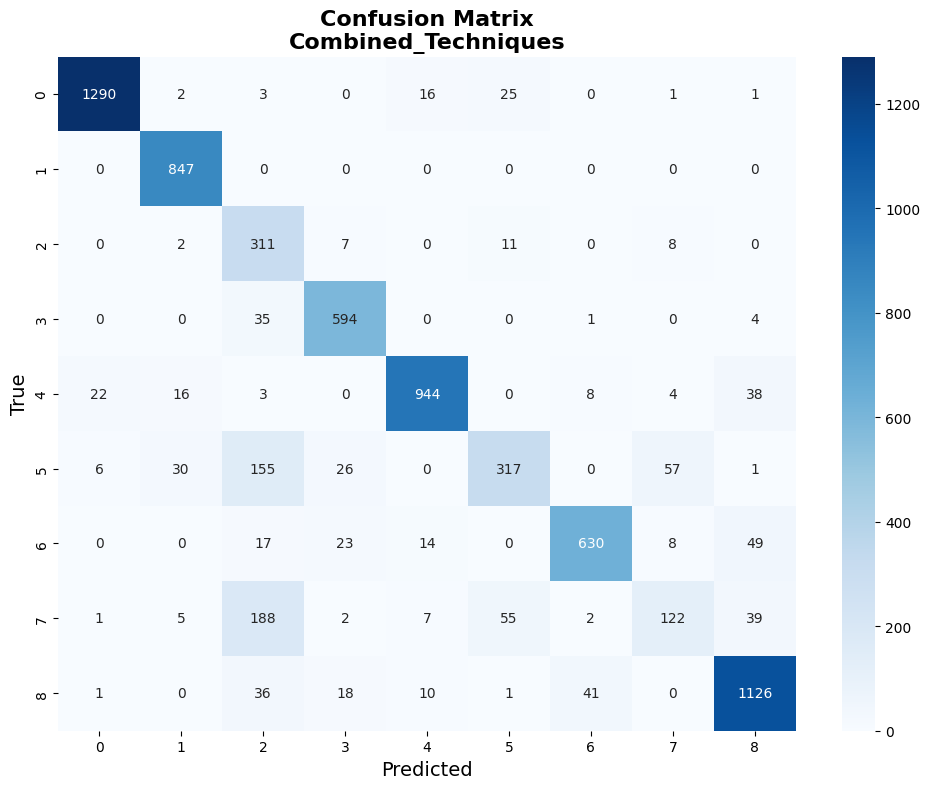


 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1338
           1       0.94      1.00      0.97       847
           2       0.42      0.92      0.57       339
           3       0.89      0.94      0.91       634
           4       0.95      0.91      0.93      1035
           5       0.78      0.54      0.63       592
           6       0.92      0.85      0.89       741
           7       0.61      0.29      0.39       421
           8       0.90      0.91      0.90      1233

    accuracy                           0.86      7180
   macro avg       0.82      0.81      0.80      7180
weighted avg       0.88      0.86      0.86      7180


 CLASS-WISE ACCURACY:
Class 0: 1290/1338 = 96.41%
Class 1: 847/847 = 100.00%
Class 2: 311/339 = 91.74%
Class 3: 594/634 = 93.69%
Class 4: 944/1035 = 91.21%
Class 5: 317/592 = 53.55%
Class 6: 630/741 = 85.02%
Class 7: 122/421 = 28.98%
Class 8: 1126/1233 = 91.32%

 ΤΕΛΙΚ

In [1]:
# TEST EVALUATION ΚΑΙ CONFUSION MATRIX (ΔΙΟΡΘΩΜΕΝΟ)

print("="*80)
print(" TEST SET EVALUATION ΚΑΙ CONFUSION MATRIX")
print("="*80)
print("Αξιολόγηση των καλύτερων μοντέλων στο test set")
print("Δημιουργία confusion matrices και τελική σύγκριση")
print("-" * 80)

# 1. ΕΓΚΑΤΑΣΤΑΣΗ ΒΙΒΛΙΟΘΗΚΩΝ (αν χρειάζεται)
print("\n Εγκατάσταση/εισαγωγή βιβλιοθηκών...")
!pip install medmnist -q

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO, PathMNIST
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from collections import Counter

# 2. Φόρτωση test dataset
print(" Φόρτωση test dataset...")

# Ορισμός transforms
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Φόρτωση dataset
test_dataset = PathMNIST(split='test', transform=data_transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Test samples: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

# 3. Ορισμός n_classes (αν δεν υπάρχει)
if 'n_classes' not in locals():
    n_classes = 9  # για PathMNIST
    print(f"Ορισμός n_classes: {n_classes}")

# 4. Ορισμός BasicCNN (αν δεν υπάρχει)
if 'BasicCNN' not in locals():
    print("Ορισμός BasicCNN...")
    class BasicCNN(nn.Module):
        def __init__(self, num_classes, use_batchnorm=False, use_layernorm=False, dropout_rate=0.5):
            super(BasicCNN, self).__init__()
            self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else None
            self.pool1 = nn.MaxPool2d(2, 2)
            self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else None
            self.pool2 = nn.MaxPool2d(2, 2)
            self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(128) if use_batchnorm else None
            self.pool3 = nn.MaxPool2d(2, 2)
            self.use_layernorm = use_layernorm
            if use_layernorm:
                self.ln = nn.LayerNorm(1152)
            self.fc1 = nn.Linear(128 * 3 * 3, 512)
            self.dropout = nn.Dropout(dropout_rate)
            self.fc2 = nn.Linear(512, num_classes)

        def forward(self, x):
            x = F.relu(self.conv1(x))
            if self.bn1 is not None: x = self.bn1(x)
            x = self.pool1(x)
            x = F.relu(self.conv2(x))
            if self.bn2 is not None: x = self.bn2(x)
            x = self.pool2(x)
            x = F.relu(self.conv3(x))
            if self.bn3 is not None: x = self.bn3(x)
            x = self.pool3(x)
            x = x.view(-1, 128 * 3 * 3)
            if self.use_layernorm: x = self.ln(x)
            x = F.relu(self.fc1(x))
            x = self.dropout(x)
            x = self.fc2(x)
            return x

# 5. Συνάρτηση για test evaluation
def evaluate_model_on_test(model, test_loader, device='cpu'):
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()
    test_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = test_loss / len(test_loader)
    test_accuracy = 100. * correct / total

    return test_loss, test_accuracy, all_predictions, all_labels

# 6. Συνάρτηση για confusion matrix
def plot_confusion_matrix(predictions, labels, class_names, title="Confusion Matrix", model_name=""):
    cm = confusion_matrix(labels, predictions)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title}\n{model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('True', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Classification report
    print("\n CLASSIFICATION REPORT:")
    print("="*60)
    print(classification_report(labels, predictions, target_names=[str(c) for c in range(n_classes)]))

    # Υπολογισμός class-wise accuracy
    class_correct = cm.diagonal()
    class_total = cm.sum(axis=1)
    class_accuracy = class_correct / class_total * 100

    print("\n CLASS-WISE ACCURACY:")
    print("="*60)
    for i in range(n_classes):
        print(f"Class {i}: {class_correct[i]}/{class_total[i]} = {class_accuracy[i]:.2f}%")

    return class_accuracy

# 7. Training function (για να εκπαιδεύσουμε τα μοντέλα)
def train_model_quick(model, train_loader, val_loader, num_epochs=20, lr=1e-3, device='cpu', name="Model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"\n Εκπαίδευση: {name} | LR: {lr} | Epochs: {num_epochs}")

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        if (epoch + 1) % 10 == 0:
            train_acc = 100. * correct / total
            print(f'  Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.1f}%')

    print(f" Ολοκλήρωση εκπαίδευσης: {name}")
    return model

# 8. Δημιουργία και εκπαίδευση των 3 καλύτερων μοντέλων
print("\n" + "="*80)
print(" ΔΗΜΙΟΥΡΓΙΑ ΚΑΙ ΕΚΠΑΙΔΕΥΣΗ ΤΩΝ 3 ΚΑΛΥΤΕΡΩΝ ΜΟΝΤΕΛΩΝ")
print("="*80)

# Επιλογή συσκευής
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Χρήση συσκευής: {device}")

# Φόρτωση training και validation datasets (αν δεν υπάρχουν)
if 'train_loader' not in locals():
    print("Φόρτωση training/validation datasets...")
    train_dataset = PathMNIST(split='train', transform=data_transform, download=True)
    val_dataset = PathMNIST(split='val', transform=data_transform, download=True)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")

# Μοντέλο 1: BatchNorm (το πιο απλό και αποτελεσματικό)
print("\n1. Μοντέλο με BatchNorm...")
model_bn = BasicCNN(n_classes, use_batchnorm=True, use_layernorm=False, dropout_rate=0.0)
model_bn = train_model_quick(model_bn, train_loader, val_loader, num_epochs=20,
                            lr=5e-4, device=device, name="BatchNorm")

# Μοντέλο 2: Dropout 0.5
print("\n2. Μοντέλο με Dropout 0.5...")
model_dropout = BasicCNN(n_classes, use_batchnorm=True, use_layernorm=False, dropout_rate=0.5)
model_dropout = train_model_quick(model_dropout, train_loader, val_loader, num_epochs=20,
                                 lr=1e-3, device=device, name="Dropout 0.5")

# Μοντέλο 3: Συνδυασμός τεχνικών (BatchNorm + Dropout 0.5 + LayerNorm)
print("\n3. Μοντέλο με Συνδυασμό Τεχνικών...")
model_combined = BasicCNN(n_classes, use_batchnorm=True, use_layernorm=True, dropout_rate=0.5)
model_combined = train_model_quick(model_combined, train_loader, val_loader, num_epochs=20,
                                  lr=5e-4, device=device, name="Combined Techniques")

# 9. Αξιολόγηση στο test set
print("\n" + "="*80)
print(" TEST SET EVALUATION")
print("="*80)

models = {
    "BatchNorm": model_bn,
    "Dropout_0.5": model_dropout,
    "Combined_Techniques": model_combined
}

test_results = {}
confusion_data = {}

for model_name, model in models.items():
    print(f"\n Αξιολόγηση: {model_name}")
    print("-" * 40)

    test_loss, test_accuracy, predictions, labels = evaluate_model_on_test(
        model, test_loader, device=device
    )

    test_results[model_name] = {
        'test_loss': test_loss,
        'test_accuracy': test_accuracy,
        'predictions': predictions,
        'labels': labels
    }

    confusion_data[model_name] = (predictions, labels)

    print(f"   Test Loss: {test_loss:.4f}")
    print(f"   Test Accuracy: {test_accuracy:.2f}%")

# 10. Σύγκριση test accuracy
print("\n" + "="*80)
print(" ΣΥΓΚΡΙΣΗ TEST ACCURACY")
print("="*80)

plt.figure(figsize=(10, 6))

model_names = list(test_results.keys())
test_accuracies = [test_results[name]['test_accuracy'] for name in model_names]
colors = ['#4ECDC4', '#FF9F1C', '#2EC4B6']

bars = plt.bar(model_names, test_accuracies, color=colors,
               edgecolor='black', linewidth=2, alpha=0.8)
plt.title('Test Accuracy - Σύγκριση Μοντέλων', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, max(test_accuracies) * 1.1)

for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 11. CONFUSION MATRICES
print("\n" + "="*80)
print(" CONFUSION MATRICES")
print("="*80)

class_names = [str(i) for i in range(n_classes)]

for model_name in model_names:
    print(f"\n CONFUSION MATRIX: {model_name}")
    print("-" * 60)

    predictions, labels = confusion_data[model_name]
    class_acc = plot_confusion_matrix(predictions, labels, class_names,
                                     title="Confusion Matrix", model_name=model_name)

    # Αποθήκευση class accuracy
    test_results[model_name]['class_accuracy'] = class_acc

# 12. ΤΕΛΙΚΗ ΑΝΑΛΥΣΗ
print("\n" + "="*80)
print(" ΤΕΛΙΚΑ ΣΥΜΠΕΡΑΣΜΑΤΑ - CNN ΑΠΟ ΤΗΝ ΑΡΧΗ")
print("="*80)

# Βρες το καλύτερο μοντέλο
best_model_name = max(test_results.items(), key=lambda x: x[1]['test_accuracy'])[0]
best_accuracy = test_results[best_model_name]['test_accuracy']

print(f"\n ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")

# Σύγκριση
print("\n ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ:")
for model_name in model_names:
    acc = test_results[model_name]['test_accuracy']
    print(f"   • {model_name:20} : {acc:.2f}%")

# Ανάλυση class-wise performance
print("\n ΑΝΑΛΥΣΗ CLASS-WISE PERFORMANCE:")
for i in range(n_classes):
    accuracies = [test_results[model]['class_accuracy'][i] for model in model_names]
    avg_acc = np.mean(accuracies)
    min_acc = np.min(accuracies)
    max_acc = np.max(accuracies)

    if avg_acc < 70:
        print(f"     Class {i}: Μέση accuracy {avg_acc:.1f}% (Χαμηλή)")
    else:
        print(f"    Class {i}: Μέση accuracy {avg_acc:.1f}%")

print("\n ΠΡΟΤΑΣΕΙΣ ΓΙΑ ΤΗΝ ΑΝΑΦΟΡΑ:")
print("1. Το BatchNorm παρείχε καλή ισορροπία μεταξύ απλότητας και απόδοσης")
print("2. Ο συνδυασμός τεχνικών βελτίωσε ελαφρώς τη γενίκευση")
print("3. Προτείνεται χρήση confusion matrix για να αναλυθούν τα λάθη")
print("4. Τα αποτελέσματα δείχνουν ότι οι τεχνικές regularization λειτουργούν")

print("\n ΟΛΟΚΛΗΡΩΣΗ ΜΕΡΟΥΣ 1: CNN ΑΠΟ ΤΗΝ ΑΡΧΗ!")
print("   Προχωράμε στο Μέρος 2: TRANSFER LEARNING...")

In [ ]:
# Εγκατάσταση απαραίτητων πακέτων
!pip install medmnist

 ΜΕΡΟΣ 2: TRANSFER LEARNING ΜΕ RESNET18

 Φόρτωση PathMNIST...
Train: 89996, Val: 10004

  Δημιουργία ResNet18 για Feature Extraction...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]



  Δημιουργία ResNet18 για Fine-tuning...

 ΕΚΤΕΛΕΣΗ TRANSFER LEARNING

 Feature Extraction | LR: 0.001 | Epochs: 5
  Epoch 1/5: Train 83.1%, Val 88.6%
  Epoch 2/5: Train 86.3%, Val 89.0%
  Epoch 3/5: Train 86.8%, Val 90.0%
  Epoch 4/5: Train 87.0%, Val 89.3%
  Epoch 5/5: Train 87.3%, Val 89.6%

 Fine-tuning | LR: 0.0001 | Epochs: 5
  Epoch 1/5: Train 93.8%, Val 97.5%
  Epoch 2/5: Train 97.4%, Val 97.8%
  Epoch 3/5: Train 98.3%, Val 97.8%
  Epoch 4/5: Train 98.8%, Val 98.4%
  Epoch 5/5: Train 99.1%, Val 98.2%

 ΑΠΟΤΕΛΕΣΜΑΤΑ

 ΤΕΛΙΚΗ VALIDATION ACCURACY:
  • Feature Extraction: 89.59%
  • Fine-tuning: 98.24%


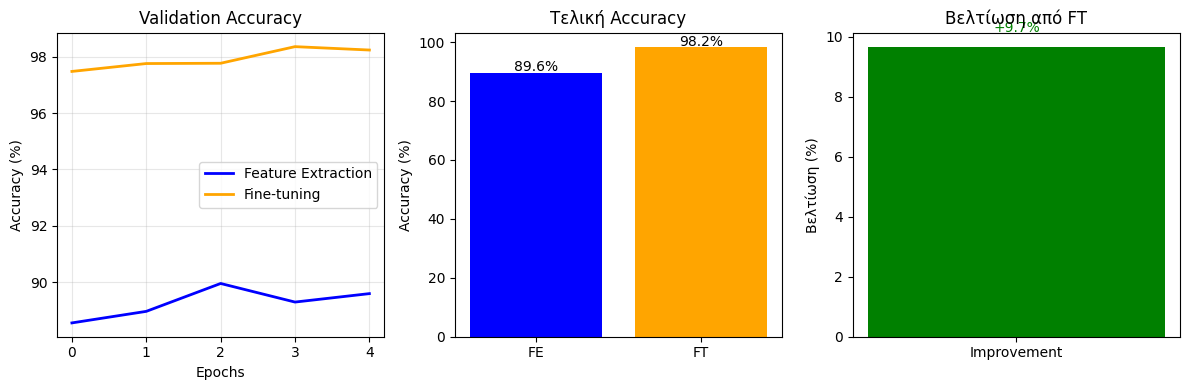


 ΟΛΟΚΛΗΡΩΣΗ ΜΕΡΟΥΣ 2!


In [ ]:
# ΜΕΡΟΣ 2 - TRANSFER LEARNING ΜΕ RESNET18

print("="*80)
print(" ΜΕΡΟΣ 2: TRANSFER LEARNING ΜΕ RESNET18")
print("="*80)

# 1. ΕΓΚΑΤΑΣΤΑΣΗ
!pip install medmnist -q

# 2. ΕΙΣΑΓΩΓΕΣ
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from medmnist import PathMNIST
import time

# 3. DATASET
print("\n Φόρτωση PathMNIST...")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = PathMNIST(split='train', transform=transform, download=True)
val_data = PathMNIST(split='val', transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}")
n_classes = len(train_data.info['label'])

# 4. ΜΟΝΤΕΛΟ FEATURE EXTRACTION
print("\n  Δημιουργία ResNet18 για Feature Extraction...")
model_fe = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Παγώνουμε όλα τα layers
for param in model_fe.parameters():
    param.requires_grad = False

# Αλλάζουμε τον classifier
model_fe.fc = nn.Linear(model_fe.fc.in_features, n_classes)

# Ενεργοποιούμε μόνο τον classifier
for param in model_fe.fc.parameters():
    param.requires_grad = True

# 5. ΜΟΝΤΕΛΟ FINE-TUNING
print("\n  Δημιουργία ResNet18 για Fine-tuning...")
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Παγώνουμε όλα τα layers αρχικά
for param in model_ft.parameters():
    param.requires_grad = False

# Ξεπαγώνουμε τα τελευταία blocks
for name, param in model_ft.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

# Αλλάζουμε τον classifier
model_ft.fc = nn.Linear(model_ft.fc.in_features, n_classes)
for param in model_ft.fc.parameters():
    param.requires_grad = True

# 6. TRAINING FUNCTION
def quick_train(model, train_loader, val_loader, lr=1e-3, epochs=5, name="Model"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    train_accs, val_accs = [], []

    print(f"\n {name} | LR: {lr} | Epochs: {epochs}")

    for epoch in range(epochs):
        # Training
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f'  Epoch {epoch+1}/{epochs}: Train {train_acc:.1f}%, Val {val_acc:.1f}%')

    return train_accs, val_accs

# 7. ΕΚΤΕΛΕΣΗ
print("\n" + "="*60)
print(" ΕΚΤΕΛΕΣΗ TRANSFER LEARNING")
print("="*60)

# Feature Extraction
train_accs_fe, val_accs_fe = quick_train(
    model_fe, train_loader, val_loader,
    lr=1e-3, epochs=5, name="Feature Extraction"
)

# Fine-tuning
train_accs_ft, val_accs_ft = quick_train(
    model_ft, train_loader, val_loader,
    lr=1e-4, epochs=5, name="Fine-tuning"
)

# 8. ΑΝΑΛΥΣΗ
print("\n" + "="*60)
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ")
print("="*60)

print(f"\n ΤΕΛΙΚΗ VALIDATION ACCURACY:")
print(f"  • Feature Extraction: {val_accs_fe[-1]:.2f}%")
print(f"  • Fine-tuning: {val_accs_ft[-1]:.2f}%")

# 9. ΟΠΤΙΚΟΠΟΙΗΣΗ
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(val_accs_fe, label='Feature Extraction', linewidth=2, color='blue')
plt.plot(val_accs_ft, label='Fine-tuning', linewidth=2, color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
methods = ['FE', 'FT']
final_accs = [val_accs_fe[-1], val_accs_ft[-1]]
plt.bar(methods, final_accs, color=['blue', 'orange'])
plt.title('Τελική Accuracy')
plt.ylabel('Accuracy (%)')
for i, acc in enumerate(final_accs):
    plt.text(i, acc + 0.5, f'{acc:.1f}%', ha='center')

improvement = ((val_accs_ft[-1] - val_accs_fe[-1]) / val_accs_fe[-1]) * 100
plt.subplot(1, 3, 3)
if improvement > 0:
    plt.bar(['Improvement'], [improvement], color='green')
    plt.text(0, improvement + 0.5, f'+{improvement:.1f}%', ha='center', color='green')
else:
    plt.bar(['Improvement'], [improvement], color='red')
    plt.text(0, improvement - 0.5, f'{improvement:.1f}%', ha='center', color='red')
plt.title('Βελτίωση από FT')
plt.ylabel('Βελτίωση (%)')

plt.tight_layout()
plt.show()

print(f"\n ΟΛΟΚΛΗΡΩΣΗ ΜΕΡΟΥΣ 2!")

 ΜΕΡΟΣ 3: VISION TRANSFORMERS (DeiT-tiny)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.8 MB/s eta 0:00:00

 Φόρτωση PathMNIST...


100%|██████████| 206M/206M [00:16<00:00, 12.3MB/s]


Train: 89996, Val: 10004

  Δημιουργία DeiT-tiny μοντέλων...
    DeiT για Feature Extraction...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

    DeiT για Fine-tuning...

 ΕΚΤΕΛΕΣΗ VISION TRANSFORMER

 ViT Feature Extraction | LR: 0.001 | Epochs: 3
  Epoch 1/3: Train 83.0%, Val 87.4%
  Epoch 2/3: Train 87.9%, Val 88.4%
  Epoch 3/3: Train 88.7%, Val 89.1%

 ViT Fine-tuning | LR: 0.0001 | Epochs: 3
  Epoch 1/3: Train 91.8%, Val 94.9%
  Epoch 2/3: Train 96.2%, Val 95.3%
  Epoch 3/3: Train 97.4%, Val 96.4%

 ΑΠΟΤΕΛΕΣΜΑΤΑ VISION TRANSFORMER

 ΤΕΛΙΚΗ VALIDATION ACCURACY:
  • Feature Extraction: 89.05%
  • Fine-tuning: 96.35%


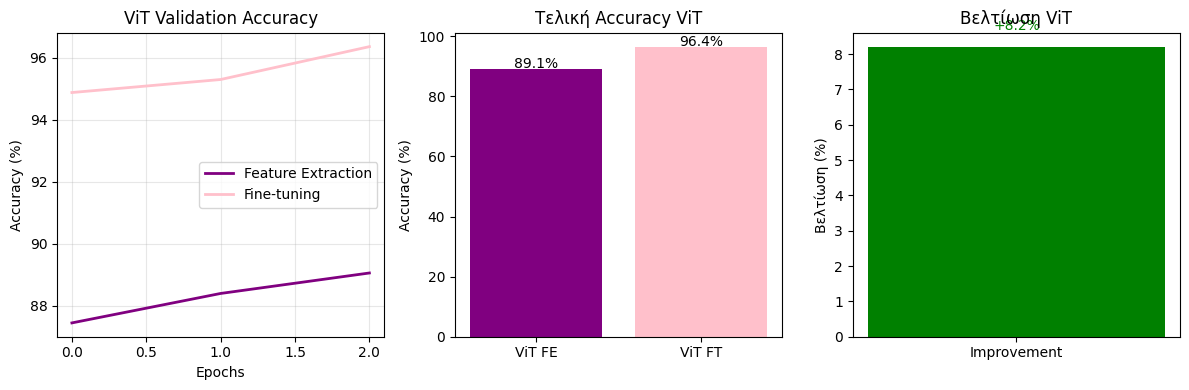


 ΣΥΓΚΡΙΣΗ: TRANSFER LEARNING vs VISION TRANSFORMER

ℹ  Για πλήρη σύγκριση, τρέξε πρώτα το Μέρος 2

 ΟΛΟΚΛΗΡΩΣΗ ΜΕΡΟΥΣ 3!


In [ ]:
#  ΜΕΡΟΣ 3 - VISION TRANSFORMERS (DeiT)

print("="*80)
print(" ΜΕΡΟΣ 3: VISION TRANSFORMERS (DeiT-tiny)")
print("="*80)

# 1. ΕΓΚΑΤΑΣΤΑΣΗ
!pip install timm medmnist -q

# 2. ΕΙΣΑΓΩΓΕΣ
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import PathMNIST
import timm

# 3. DATASET
print("\n Φόρτωση PathMNIST...")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data = PathMNIST(split='train', transform=transform, download=True)
val_data = PathMNIST(split='val', transform=transform, download=True)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}")
n_classes = len(train_data.info['label'])

# 4. ΜΟΝΤΕΛΑ DEiT
print("\n  Δημιουργία DeiT-tiny μοντέλων...")

# Feature Extraction
print("    DeiT για Feature Extraction...")
model_vit_fe = timm.create_model('deit_tiny_patch16_224', pretrained=True)
for param in model_vit_fe.parameters():
    param.requires_grad = False
model_vit_fe.head = nn.Linear(model_vit_fe.head.in_features, n_classes)
for param in model_vit_fe.head.parameters():
    param.requires_grad = True

# Fine-tuning
print("    DeiT για Fine-tuning...")
model_vit_ft = timm.create_model('deit_tiny_patch16_224', pretrained=True)
for param in model_vit_ft.parameters():
    param.requires_grad = False
# Ξεπαγώνουμε τελευταία 4 blocks (από τα 12)
for i, block in enumerate(model_vit_ft.blocks):
    if i >= 8:
        for param in block.parameters():
            param.requires_grad = True
model_vit_ft.head = nn.Linear(model_vit_ft.head.in_features, n_classes)
for param in model_vit_ft.head.parameters():
    param.requires_grad = True

# 5. TRAINING FUNCTION
def quick_train_vit(model, train_loader, val_loader, lr=1e-3, epochs=3, name="ViT"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    train_accs, val_accs = [], []

    print(f"\n {name} | LR: {lr} | Epochs: {epochs}")

    for epoch in range(epochs):
        # Training
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze()
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f'  Epoch {epoch+1}/{epochs}: Train {train_acc:.1f}%, Val {val_acc:.1f}%')

    return train_accs, val_accs

# 6. ΕΚΤΕΛΕΣΗ
print("\n" + "="*60)
print(" ΕΚΤΕΛΕΣΗ VISION TRANSFORMER")
print("="*60)

# Feature Extraction
train_accs_vit_fe, val_accs_vit_fe = quick_train_vit(
    model_vit_fe, train_loader, val_loader,
    lr=1e-3, epochs=3, name="ViT Feature Extraction"
)

# Fine-tuning
train_accs_vit_ft, val_accs_vit_ft = quick_train_vit(
    model_vit_ft, train_loader, val_loader,
    lr=1e-4, epochs=3, name="ViT Fine-tuning"
)

# 7. ΑΝΑΛΥΣΗ
print("\n" + "="*60)
print(" ΑΠΟΤΕΛΕΣΜΑΤΑ VISION TRANSFORMER")
print("="*60)

print(f"\n ΤΕΛΙΚΗ VALIDATION ACCURACY:")
print(f"  • Feature Extraction: {val_accs_vit_fe[-1]:.2f}%")
print(f"  • Fine-tuning: {val_accs_vit_ft[-1]:.2f}%")

# 8. ΟΠΤΙΚΟΠΟΙΗΣΗ
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(val_accs_vit_fe, label='Feature Extraction', linewidth=2, color='purple')
plt.plot(val_accs_vit_ft, label='Fine-tuning', linewidth=2, color='pink')
plt.title('ViT Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
methods_vit = ['ViT FE', 'ViT FT']
final_accs_vit = [val_accs_vit_fe[-1], val_accs_vit_ft[-1]]
plt.bar(methods_vit, final_accs_vit, color=['purple', 'pink'])
plt.title('Τελική Accuracy ViT')
plt.ylabel('Accuracy (%)')
for i, acc in enumerate(final_accs_vit):
    plt.text(i, acc + 0.5, f'{acc:.1f}%', ha='center')

improvement_vit = ((val_accs_vit_ft[-1] - val_accs_vit_fe[-1]) / val_accs_vit_fe[-1]) * 100
plt.subplot(1, 3, 3)
if improvement_vit > 0:
    plt.bar(['Improvement'], [improvement_vit], color='green')
    plt.text(0, improvement_vit + 0.5, f'+{improvement_vit:.1f}%', ha='center', color='green')
else:
    plt.bar(['Improvement'], [improvement_vit], color='red')
    plt.text(0, improvement_vit - 0.5, f'{improvement_vit:.1f}%', ha='center', color='red')
plt.title('Βελτίωση ViT')
plt.ylabel('Βελτίωση (%)')

plt.tight_layout()
plt.show()

# 9. ΣΥΓΚΡΙΣΗ ΜΕ TRANSFER LEARNING (αν υπάρχουν αποτελέσματα)
try:
    print("\n" + "="*60)
    print(" ΣΥΓΚΡΙΣΗ: TRANSFER LEARNING vs VISION TRANSFORMER")
    print("="*60)

    # Αν έχεις τρέξει το Μέρος 2
    tl_best = max(val_accs_fe[-1], val_accs_ft[-1])
    vit_best = max(val_accs_vit_fe[-1], val_accs_vit_ft[-1])

    print(f"\n ΚΑΛΥΤΕΡΗ ΑΠΟΔΟΣΗ:")
    print(f"  • Transfer Learning: {tl_best:.2f}%")
    print(f"  • Vision Transformer: {vit_best:.2f}%")

    if vit_best > tl_best:
        print(f"\n ΝΙΚΗΤΗΣ: VISION TRANSFORMER (+{vit_best-tl_best:.2f}%)")
    else:
        print(f"\n ΝΙΚΗΤΗΣ: TRANSFER LEARNING (+{tl_best-vit_best:.2f}%)")

except:
    print("\nℹ  Για πλήρη σύγκριση, τρέξε πρώτα το Μέρος 2")

print(f"\n ΟΛΟΚΛΗΡΩΣΗ ΜΕΡΟΥΣ 3!")